## Introduction

### Contexte

L'agence Santé publique France souhaite améliorer sa base de données Open Food Facts et fait appel aux services de votre entreprise. Cette base de données open source est mise à la disposition de particuliers et d’organisations afin de leur permettre de connaître la qualité nutritionnelle de produits. 
 
Aujourd’hui, pour ajouter un produit à la base de données d'Open Food Facts, il est nécessaire de remplir de nombreux champs textuels et numériques, ce qui peut conduire à des erreurs de saisie et à des valeurs manquantes dans la base. 

L’agence Santé publique France confie à votre entreprise la création d’un système de suggestion ou d’auto-complétion pour aider les usagers à remplir plus efficacement la base de données. Dans un premier temps, vous devez vous concentrer sur la prise en main des données, et d’abord les nettoyer et les explorer. 

### Problématique

__Est-il possible de suggérer des valeurs pour certains champs lors de l'ajout d'un nouveau produit afin de réduire les erreurs de saisie et les valeurs manquantes dans la base de données Open Food Facts ?__

### Objectifs

- Identifier les variables cibles pour lesquelles il serait pertinent de suggérer des valeurs (plus de 50% de valeurs manquantes).
- Identifier les variables nécessaires pour lesquelles il est important d'avoir des données.
- Filtrer 
- Mettre en évidence les valeurs manquantes
- Identifier 3 méthodes adaptées (métiers) pour traiter ces valeurs manquantes.
- Automatiser les traitements pour éviter de répéter les opérations.


- Se servir de ces variables nécessaires pour tenter de faire des suggestions sur les variables avec des valeurs manquantes.

- Etablir la faisabilité de suggérer les valeurs manquantes pour une variable dont plus de 50% des valeurs sont manquantes.

### About RGPD

- Expliquer que la RGPD ne s'applique que dans le cadre de la manipulation de données personnelles.
- Détailler les grands principes des RGPD et en quoi ce projet reste tout de même cohérent avec ces principes.
- Expliquer ce qu'et une donnée personnelle et conclure que dans ce projet n'a pas de lien avec les RGPD.

## Imports and setup

In [1]:
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install missingno
%pip install googletrans==4.0.0-rc1
%pip install geopy
%pip install tqdm
%pip install -U scikit-learn
%pip install scipy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   --- ------------------------------------ 1.0/11.1 MB 7.1 MB/s eta 0:00:02
   ------- -------------------------------- 2.1/11.1 MB 6.2 MB/s eta 0:00:02
   -------------- ------------------------- 3.9/11.1 MB 6.3 MB/s eta 0:00:02
   --------------------- ------------------ 6.0/11.1 MB 7.4 MB/s eta 0:00:01
   ----------------------------- ---------- 8.1/11.1 MB 8.0 MB/s eta 0:00:01
   -------------------------------- ------- 9.2/11.1 MB 8.3 MB/s eta 0:00:01
   ---

In [103]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.spatial.distance import euclidean, cdist, pdist, squareform
from itertools import combinations
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import matplotlib.dates as mdates
import seaborn as sns
from typing import Optional, Callable
import missingno as msno
import re
import math
from googletrans import Translator
from tqdm import tqdm
from functools import partial
from geopy.geocoders import Nominatim
from httpx import Timeout
from tqdm import tqdm
# from sklearn.feature_selection import f_classif
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import NearestNeighbors
import cProfile
tqdm.pandas()

timeout=Timeout(10.0)
translator = Translator(user_agent="DS-3", timeout=timeout)

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_17020\2759280587.py:10: DtypeWarning: Columns (0,3,5,19,20,24,25,26,27,28,35,36,37,38,39,48) have mixed types. Specify dtype option on import or set low_memory=False.
  products = pd.read_csv('fr.openfoodfacts.org.products.csv', sep="\t", low_memory=True)


Here are the 24 products with incorrect datetime format:
21 columns were removed : 'ingredients_from_palm_oil', 'nutrition_grade_uk', 'cerotic-acid_100g', 'no_nutriments', 'behenic-acid_100g', 'elaidic-acid_100g', 'ingredients_that_may_be_from_palm_oil', 'erucic-acid_100g', 'allergens_fr', 'mead-acid_100g', 'caproic-acid_100g', 'dihomo-gamma-linolenic-acid_100g', 'nervonic-acid_100g', 'chlorophyl_100g', 'lignoceric-acid_100g', 'water-hardness_100g', 'cities', 'butyric-acid_100g', 'glycemic-index_100g', 'gondoic-acid_100g', 'melissic-acid_100g'
This DataFrame has 320749 rows and 122 columns.
This DataFrame has 68886 rows and 36 columns.


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_17020\2759280587.py:70: UserWarning: Unable to sort modes: '<' not supported between instances of 'str' and 'int'
  modes = s.mode()


No correlated features found for target 'additives_n'.
No correlated features found for target 'ingredients_from_palm_oil_n'.
No correlated features found for target 'ingredients_that_may_be_from_palm_oil_n'.
No correlated features found for target 'energy_100g'.
No correlated features found for target 'fat_100g'.
No correlated features found for target 'saturated-fat_100g'.
No correlated features found for target 'carbohydrates_100g'.
No correlated features found for target 'sugars_100g'.
No correlated features found for target 'proteins_100g'.
1 values of target 'salt_100g' can be predicted using features 'sodium_100g'.
3 values of target 'sodium_100g' can be predicted using features 'salt_100g'.
11988 values of target 'nutrition-score-fr_100g' can be predicted using features 'nutrition-score-uk_100g'.
No value of target 'nutrition-score-uk_100g' can be predicted using features 'nutrition-score-fr_100g'.


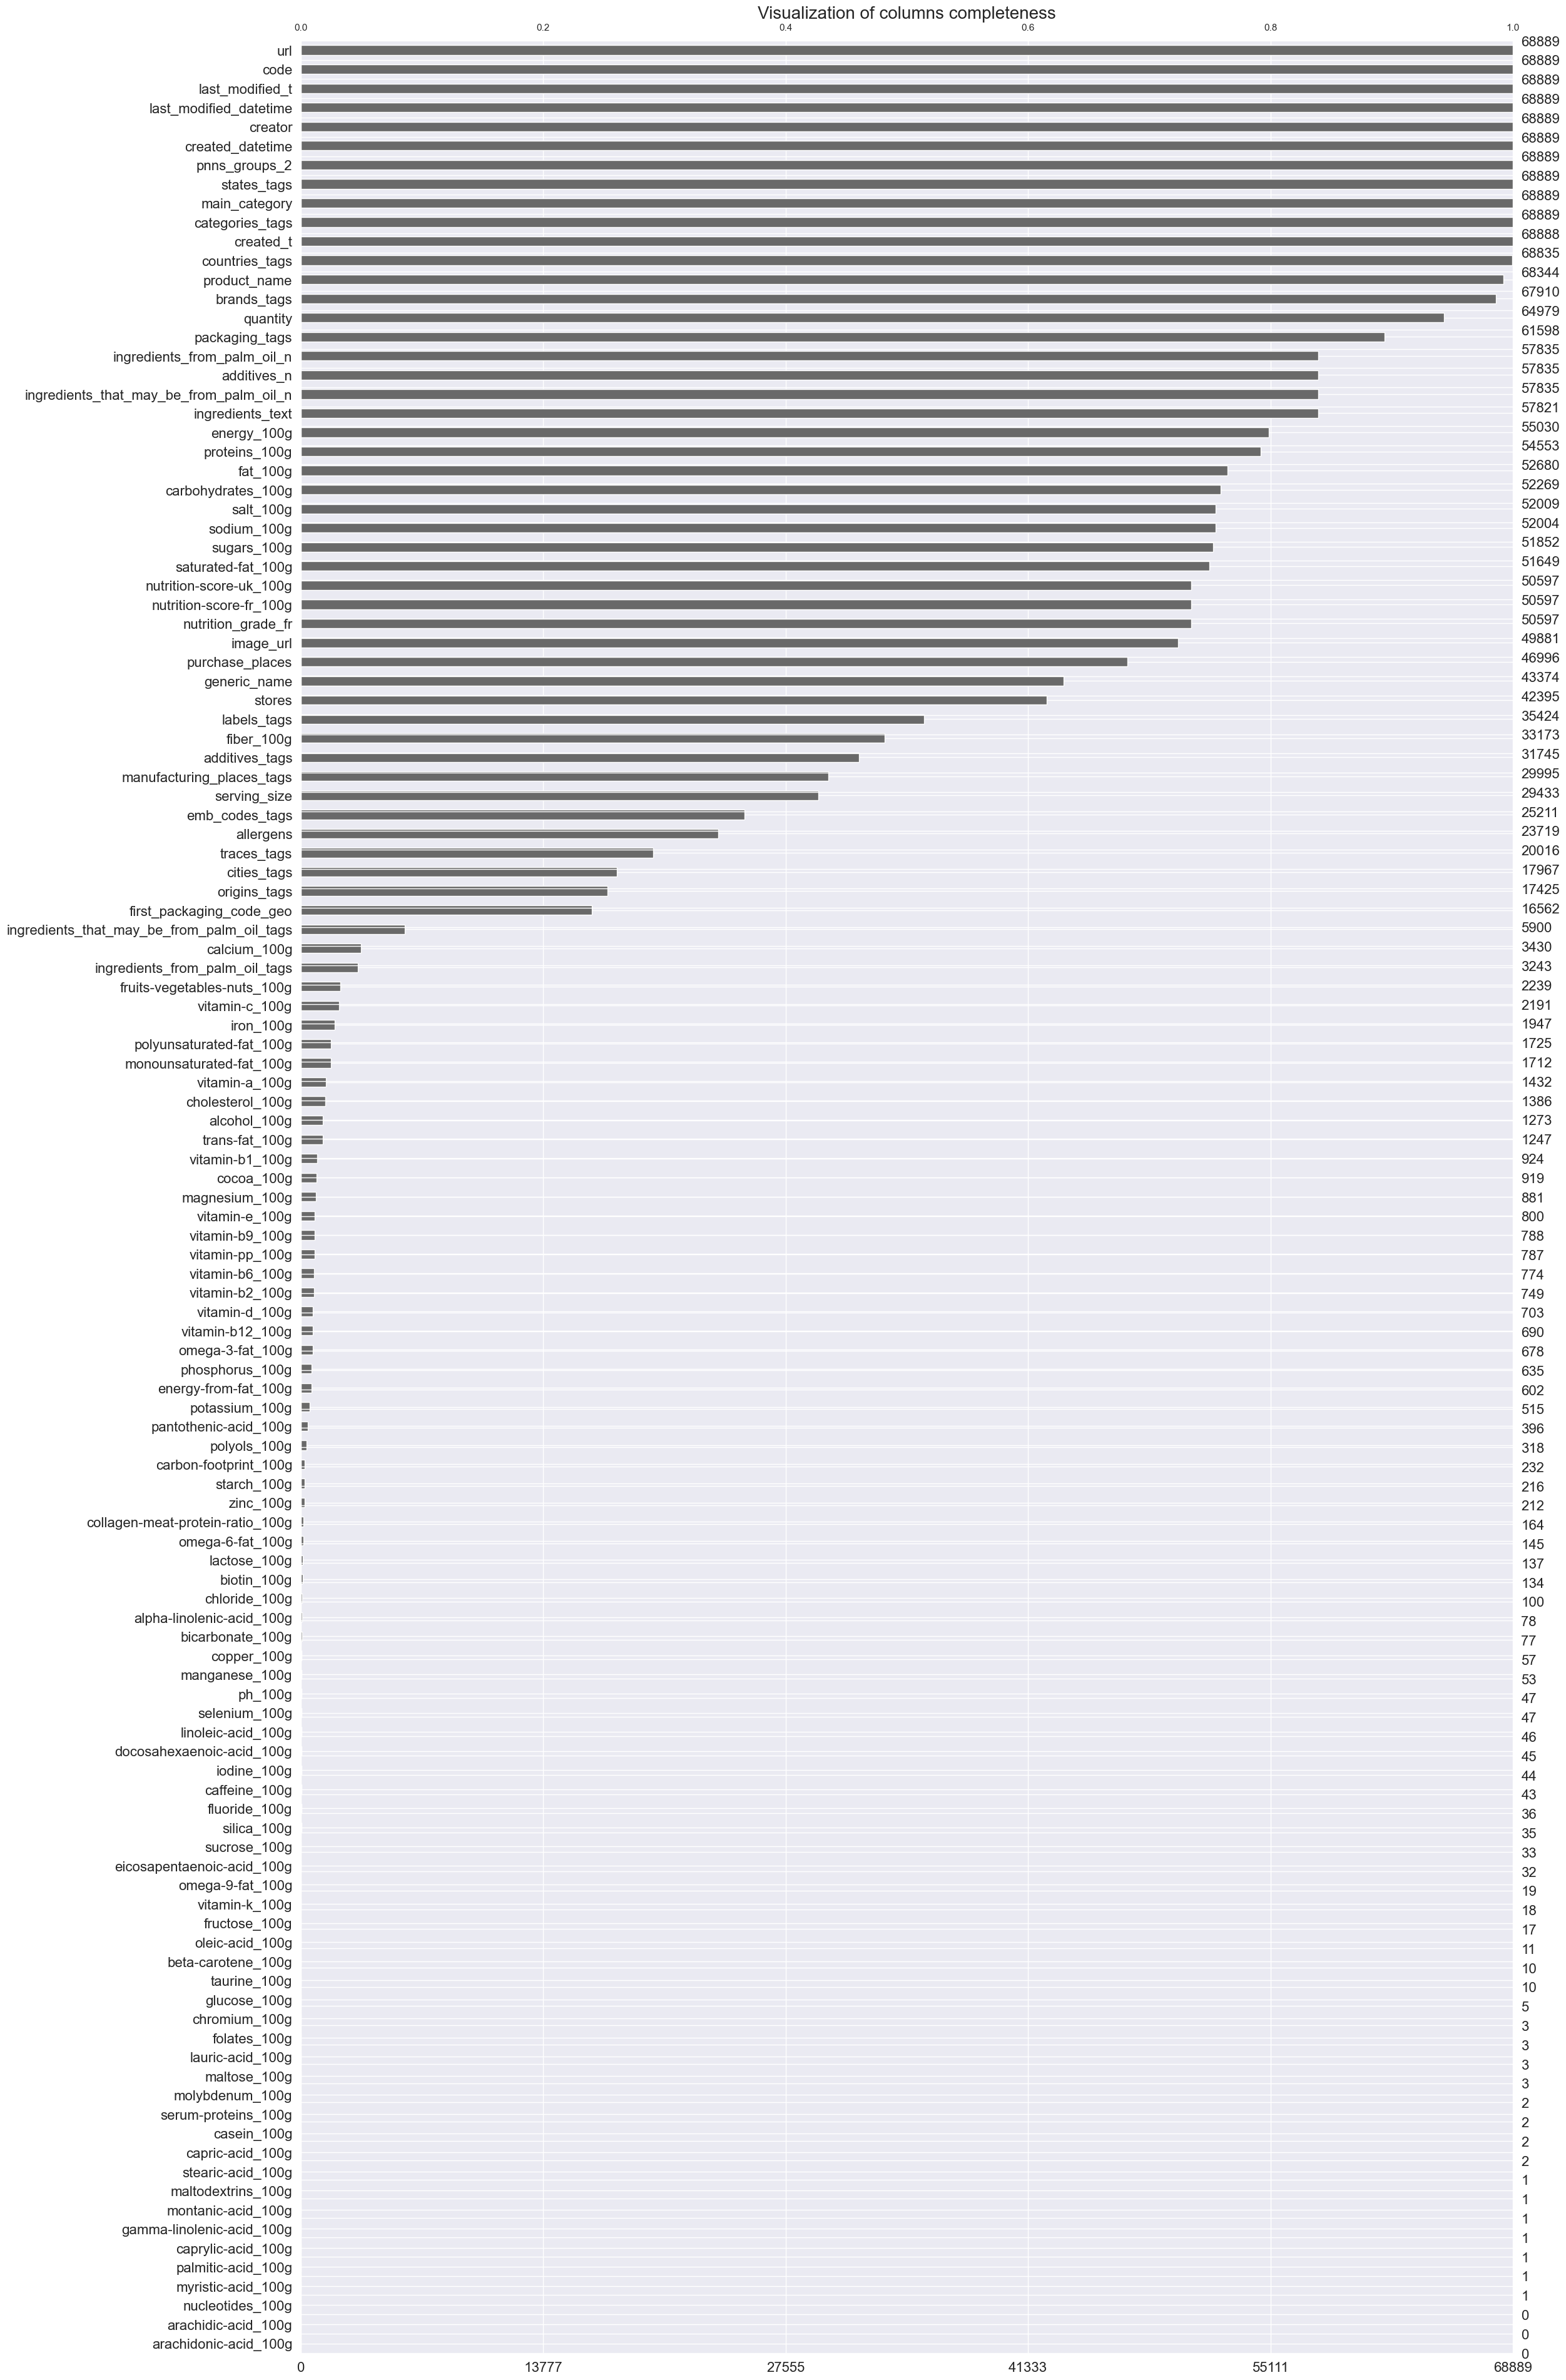

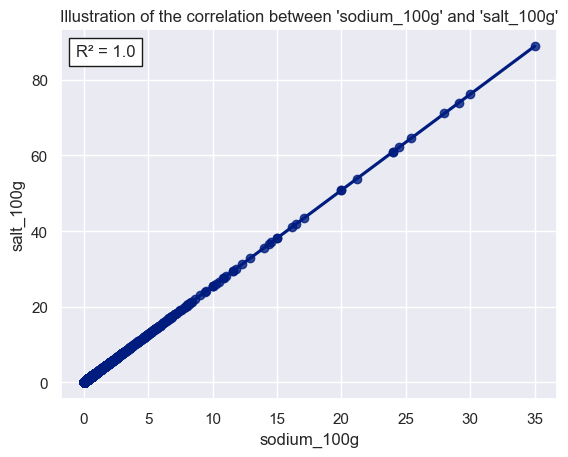

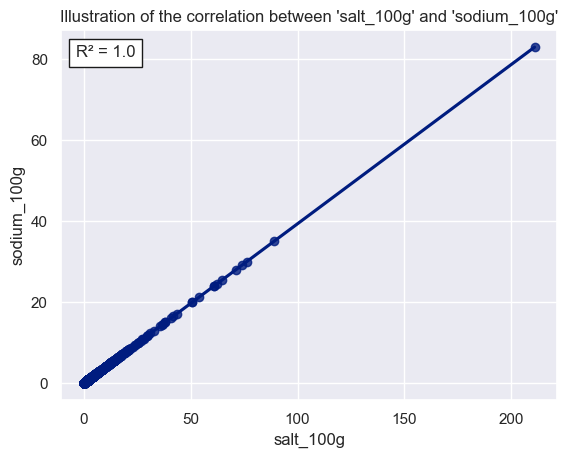

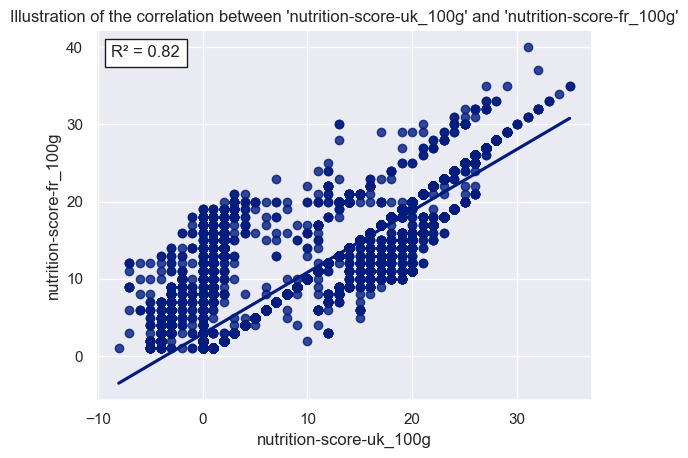

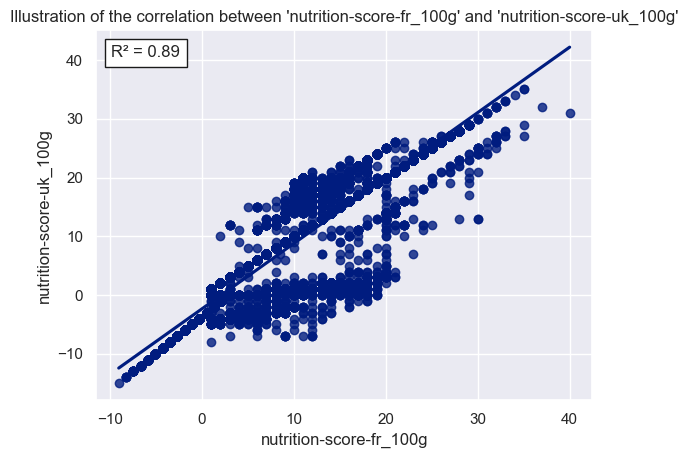

In [2]:
# Data collection

# Using low_memory = False to remove the DTypeWarning resulted in "code" column being modified.
# For example :
# low_memory = True : 11778, 11778
# low_memory = False : 0011778, 00011778
# All duplicates seem to be removed like this with low_memory = False

# Collect data and store it in a DataFrame
products = pd.read_csv('fr.openfoodfacts.org.products.csv', sep="\t", low_memory=True)

def check_for_mixed_types(df:pd.DataFrame) -> list:
    '''
    Checks a DataFrame for columns with inconsistent types.

    Parameters:
    df (pd.Dataframe): DataFrame to check

    Returns:
    List of column with inconsistent types.
    '''
    cols_mixed_types = []
    for col in df.columns:
        weird = (df[[col]].map(type) != df[[col]].iloc[0].apply(type)).any(axis=1)
        if len(df[weird]) > 0:
            cols_mixed_types.append(col)
    
    print(f"{len(cols_mixed_types)} column(s) have inconsistent types.")
    
    return cols_mixed_types

# Set the seaborn theme for plots
sns.set_theme(palette="dark")

def display_unique_values(s:pd.Series, df:pd.DataFrame):
    n_unique_values = df.loc[s.name, "nbr_unique_values"]
    if n_unique_values == 0:
        return "no value"
    if n_unique_values < 6:
        return ", ".join(f"{s.value_counts().index[i]} ({v} occurrences)" for i, v in enumerate(s.value_counts()))
    
    return "too many to display"


def add_additional_comment(s:pd.Series, df:pd.DataFrame, sensitivity:float):   
    value_counts = s.value_counts()

    if len(value_counts) > 0:
        # Calculate top common values based on sensitivity
        n_top_common_values = int(len(value_counts) * sensitivity)
        top_common_values = value_counts.values[:n_top_common_values]
        
        # Check if the top common values represent a significant proportion of the data
        if value_counts.quantile(1 - sensitivity) / value_counts.max() < 0.25 and n_top_common_values <= 10:
            sum_top_common_values = top_common_values.sum()
            top_common_values_prop = round(sum_top_common_values / df.loc[s.name, "nbr_non_null_values"], 2)
            top_common_values_info = [f"{value_counts.index[i]} ({value})" for i, value in enumerate(top_common_values)]
            
            # Print additional comments on common values
            return f"""First {n_top_common_values} unique values represent {top_common_values_prop * 100}% of total values : {', '.join(top_common_values_info)}"""
        
        return
    
    else:
        return "This column only contains null values."


def compute_modes(s:pd.Series):
    value_counts = s.value_counts()
    modes = s.mode()
    n_modes = len(modes)

    if n_modes > 0:
        return ", ".join(str(v) if i < 3 else f"... ({n_modes} elements)" for i, v in enumerate(modes[:min(n_modes, 4)])) + f" ({value_counts.values[0]} occurrence(s))"
    
    return


def get_df_variables_info(df:pd.DataFrame) -> pd.DataFrame:

    (n_rows, n_columns) = df.shape
    print(f"This DataFrame has {n_rows} rows and {n_columns} columns.")
    
    top_common_values_sensitivity = 0.15

    n_unique_values = df.nunique()
    n_values = df.count()

    df_info = pd.DataFrame({
        'column_type':df.dtypes,
        'missing_value_percentage': (df.isnull().mean()*100).round(3),
        'nbr_unique_values': n_unique_values,
        'nbr_null_values': df.isnull().sum(),
        'nbr_non_null_values': n_values,
        'duplicates_percentage':round(100-n_unique_values/(n_values.where(n_values != 0, np.nan))*100, 2),
        'mode': df.apply(compute_modes),
        'min': df.min(numeric_only=True),
        'max': df.max(numeric_only=True),
        'mean': df.mean(numeric_only=True),
        'median': df.median(numeric_only=True),
        'std': df.std(numeric_only=True)
        })

    df_info["unique_values"] = df.apply(display_unique_values, df=df_info)
    df_info["additional_comment"] = df.apply(add_additional_comment, df=df_info, sensitivity=top_common_values_sensitivity)

    return df_info

# Create a new column with formatted datetime, and highlight errors with NaT.
products["last_modified_datetime_formatted"] = pd.to_datetime(products["last_modified_datetime"], errors='coerce')
products["created_datetime_formatted"] = pd.to_datetime(products["created_datetime"], errors='coerce')

annoying_products = products.loc[products["last_modified_datetime_formatted"].isna() | products["created_datetime_formatted"].isna()]

print(f"Here are the {len(annoying_products)} products with incorrect datetime format:")
annoying_products[["code", "product_name", "created_datetime", "last_modified_datetime"]]

# Remove index 187478 from annoying products
annoying_products = annoying_products.drop(index=187478)

# Remove annoying products from products
products = products.drop(index=annoying_products.index).reset_index(drop=True)

# Replace missing created_datetime with corresponding last_modified_datetime
# Ideally, we could impute created_datetime value based on created_t column, but created_t is 0 for index 187478.
products.loc[187478, "created_datetime_formatted"] = products.loc[187478, "last_modified_datetime_formatted"]

# Replace "created_datetime" with custom "created_datetime_formatted" column
products["created_datetime"] = products["created_datetime_formatted"]
# Replace "last_modified_datetime" with custom "last_modified_datetime_formatted" column
products["last_modified_datetime"] = products["last_modified_datetime_formatted"]
# Remove custom columns created previously to identify incorrect date formats
products = products.drop(columns=["created_datetime_formatted", "last_modified_datetime_formatted"])


def standardize_str(s:str, escape_chars:list=[]):
    if pd.isnull(s):
        return s
    escape_pattern = ''.join(re.escape(char) for char in escape_chars)
    pattern = r'[^\w' + escape_pattern + r']'
    return re.sub(pattern, '', str(s)).lower()

def find_hidden_missing_values(df:pd.DataFrame, standardize:bool=True, print_result:bool = True, impute_nan:bool=False, additional_hidden_null_values:list[str] = ["unknown", "null", "nan", "na", "0", "inconnu", "unavailable", "not stated"]):   
    df_copy = df.copy()

    for col in df_copy:
        if standardize:
            data = df_copy[col].map(standardize_str)
        else:
            data = df_copy[col]
        contains_alphanumeric = data.str.contains(pat=r'\w', na=True, regex=True)
        hidden_null_values_condition = ~contains_alphanumeric | data.isin(additional_hidden_null_values)
        
        if hidden_null_values_condition.any():
            if print_result:
                hidden_null_values = df_copy.loc[hidden_null_values_condition, col]
                print(f"{col}:\n{hidden_null_values}\n{'*'*30}\n")
            if impute_nan:
                df_copy.loc[hidden_null_values_condition, col] = np.nan
    
    if impute_nan:
        return df_copy
    
# Fix some product names after checking their page using the provided url
products.loc[268391, "product_name"] = "5 stars"
products.loc[268392, "product_name"] = "3 stars"
products.loc[315650, "product_name"] = "Dors Tequila"

# Update products_objects_columns to take last changes into account
products_object_columns = products.select_dtypes(include=object)
products_object_columns = products_object_columns.dropna(axis='columns', how='all')

products_object_columns = find_hidden_missing_values(df=products_object_columns, standardize=True, print_result=False, impute_nan=True)

# Replace objsct columns with the new object columns (with hiddent null values imputed as NaN)
products[products_object_columns.columns] = products_object_columns

products.drop(columns="additives", inplace=True)

columns_before = set(products.columns)
products.dropna(axis=1, how="all", inplace=True)
removed_columns = columns_before.difference(set(products.columns))
print(f"""{len(removed_columns)} columns were removed : '{"', '".join(removed_columns)}'""")


# Remove duplicated columns
columns_to_drop = [
    "image_small_url", # duplicate of image_url
    "additives_fr", # french duplicate of additives_tags
    "brands", # unstandardized duplicate of brands_tags
    "categories", # unstandardized duplicate of categories_tags
    "categories_fr", # french duplicate of categories_tags
    "countries", # unstandardized duplicate of countries_tags
    "countries_fr", # french duplicate of countries_tags
    "emb_codes", # unstandardized duplicate of emb_code_tags
    "labels", # unstandardized duplicate of labels_tags
    "labels_fr", # french duplicate of labels_tags
    "main_category_fr", # french duplicate of main_category
    "manufacturing_places", # unstandardized duplicate of manufacturing_places_tags
    "origins", # unstandardized duplicate of origins_tags
    "packaging", # unstandardized duplicate of packaging_tags
    "states", # duplicate of states_tags
    "states_fr", # french duplicate of state_tags
    "traces", # unstandardized duplicate of traces_tags
    "traces_fr" # french duplicate of traces_tags
]

products.drop(columns=columns_to_drop, inplace=True)


# Update products_info
products_info = get_df_variables_info(products)

def visualize_col_completeness(df:pd.DataFrame) -> None:
    # Visualize percentage of null values in columns of non_target_data
    fig, ax = plt.subplots(figsize=(25, (len(df.columns) - 25)*0.5))
    msno.bar(df, sort="ascending", ax=ax)
    ax.set_title("Visualization of columns completeness", fontdict={'fontsize':20})


def filter_to_keep_relevant_features(df: pd.DataFrame, target:str, visualize:bool=False) -> pd.DataFrame:

    # Remove products where there is no value for target variable
    filtered_products = df.dropna(subset=target)

    # Remove the target from the dataset
    features_data = filtered_products.drop(columns=target)

    # Define columns that will be irrelevant no matter what target is choosen.
    always_irrelevant_columns = ["code", "url", "last_modified_datetime", "last_modified_t", "created_datetime", "created_t", "image_url"]
    
    features_data.drop(columns=always_irrelevant_columns, inplace=True)

    if visualize:
        visualize_col_completeness(features_data)

    # Only keep columns with sufficient data (over 50%)
    relevant_features_data = features_data[features_data.columns[features_data.notna().mean() > 0.5]]

    # Remove duplicates (i.e. products with the same code, because even though they have different urls, those all redirect to the same page of the same product.)
    return relevant_features_data.drop_duplicates(subset=["code"])


filtered_data = filter_to_keep_relevant_features(df=products, target="pnns_groups_1", visualize=True)
test=filtered_data.copy()

def formatString(s:str):
    s = s.replace('-', ' ')
    s = s.strip()
    match = re.match(r'\w{2}:(.*)', s)
    if match:
        s = match.group(1)
    match = re.match(r'\w{2}:(.*)', s)
    if match:
        s = match.group(1)
    return s.lower()

def translateString(s:str):
    translator = Translator(user_agent = "DS_3_bis")
    s = translator.translate(s).text
    print(s)
    return s

raw_individual_countries = filtered_data["countries_tags"].dropna().str.split(',').explode().unique()
countries_df = pd.DataFrame({'initial':raw_individual_countries}, columns=["initial", "formatted", "suggestions"])

geolocator = Nominatim(user_agent="DS-3", timeout=5)
geocode = partial(geolocator.geocode, language="en")

def splitString(s:str):
    splitted_s = s.split(':')
    if len(splitted_s) > 1:
        return splitted_s[1]
    else:
        return splitted_s[0]

def formatString(s:str):
    '''
    Parameters:
    s (str) : string to format

    Returns : The formatted string (only part after ":" kept, dashes replaced by whitespaces, numbers removed)
    '''
    s = s.replace('-', ' ')
    s = re.sub(r'\d', '', s)

    return s.strip()


def getCountry(string:str, compute_type:str='safe', geocode:partial=geocode):
    '''
    Parameters:
    string (str) : initial string from which country should be determined
    compute_type (str) : Can be "safe" or "raw". 
        "safe" : First considers that "string" is a country ('US' for example), if no result it considers that "string" is a state or a county ('Great Britain' for example), then it considers
            it as a city ('Marseille' for example)
        "raw" : "string" can be anything (a street, a part of an adress or a building for example). This gives result more often but can be less accurate
    geocode (partial) : partial instance to use as geocode

    Returns :
    '''
    granularities = ['country', 'state', 'county', 'city']
    if compute_type == 'raw':
        result = geocode(string)
        if result is not None and len(result) > 0:
            importance = float(result.raw["importance"])
            country = result[0].split(', ')[-1]
            
            return (country, importance)
    
    else:
        for g in granularities:
            result = geocode({g:string})
            if result is not None and len(result) > 0:
                importance = float(result.raw["importance"])
                country = result[0].split(', ')[-1]
                
                return (country, importance)

    return None, 0

def isUnique(s):
    '''
    Parameters:
    s (pd.Series) : Series for which we want to check if all the values are the same

    Returns : The unique value of the series or False if there are different values
    '''
    a = s.to_numpy()
    if (len(a) > 0) and (a[0] == a).all():
        return a[0]
    return False


def formatCountry(s:str, translator:Translator=translator):
    splitted_s = splitString(s)
    formatted_s = formatString(splitted_s)
    translated_s = translator.translate(formatted_s).text
    
    suggestions_df = pd.DataFrame(
        {'raw':getCountry(splitted_s, compute_type='raw'), 
         'formatted':getCountry(formatted_s), 
         'translated':getCountry(translated_s)
        }, 
        index=['suggestion', 'importance']
        ).transpose()

    unique_v = isUnique(suggestions_df["suggestion"])
    if unique_v:
        return unique_v
    
    unique_probable_v = isUnique(suggestions_df.loc[suggestions_df["importance"] > 0.85, "suggestion"])
    if unique_probable_v:
        return unique_probable_v
    
    suggestions_df = suggestions_df.sort_values(by="importance", ascending=False)
    countries_df.loc[countries_df["initial"] == s, "suggestions"] = ", ".join(suggestions_df["suggestion"].dropna().drop_duplicates().to_list())
    return np.nan


countries_df = pd.read_csv('countries_mapping_suggestions.csv', sep= ';')

countries_df.loc[countries_df["initial"] == "en:soviet-union", 'formatted'] = getCountry("Russia")[0]
countries_df.loc[countries_df["initial"] == "other-العراق", 'formatted'] = getCountry("العراق")[0]
countries_df.loc[countries_df["initial"] == "en:gulf-countries", 'formatted'] = "United Arab Emirates"
countries_df.loc[countries_df["initial"] == "en:republique-de-chine", 'formatted'] = "China"
countries_df.loc[countries_df["initial"] == "other-turquie", 'formatted'] = "Turkey"

united_kingdom = ["es:nagy-britannia", "fr:nagy-britannia"]
countries_df.loc[countries_df["initial"].isin(united_kingdom), 'formatted'] = "United Kingdom"

japan = ["other-japon", "en:other-日本", "other-日本"]
countries_df.loc[countries_df["initial"].isin(japan), 'formatted'] = "Japan"

france = ["fr:bourgogne-aube-nogent-sur-seine", "fr:bouches-du-rhone", "fr:77-provins"]
countries_df.loc[countries_df["initial"].isin(france), 'formatted'] = "France"

# Add "World" option
world = ["en:world", "en:worldwide", "de:weltweit", "en:global-market", "en:all-over-the-world"]
countries_df.loc[countries_df["initial"].isin(world), 'formatted'] = "World"

# Add "Europe" option
europe = ["en:european-union"]
countries_df.loc[countries_df["initial"].isin(europe), 'formatted'] = "Europe"

# Set remaining NaN values to empty string
countries_df.loc[countries_df["formatted"].isna(), 'formatted'] = ""

mapping_dict = countries_df.set_index('initial')['formatted'].to_dict()

initial_values = [v.split(',')  if isinstance(v, str) else [np.nan] for v in filtered_data['countries_tags']]

filtered_data['countries_tags'] = [','.join([mapping_dict[v] for v in values]) if isinstance(values[0], str) else np.nan for values in initial_values]

filtered_data_info = get_df_variables_info(filtered_data)

def splitString(s:str):
    splitted_s = s.split(':')
    if len(splitted_s) > 1:
        return splitted_s[1]
    else:
        return splitted_s[0]

def formatString(s:str):
    '''
    Parameters:
    s (str) : string to format

    Returns : The formatted string (only part after ":" kept, dashes replaced by whitespaces, numbers removed)
    '''
    s = s.replace('-', ' ')
    s = re.sub(r'\d', '', s)

    return s.strip()


# Apply a list of functions to transform the data
def transform_data(df:pd.DataFrame|pd.Series, funcs:list[Callable]):
    '''
    Applies a list of functions to transform the DataFrame.
    Parameters:
    df (pd.DataFrame): DataFrame to transform.
    funcs (list[Callable]): List of functions to apply to the DataFrame.
    Returns:
    pd.DataFrame: Transformed DataFrame.
    '''
    df_copy = df.copy()
    if funcs is not None and len(funcs) > 0:
        for f in funcs:
            try:
                # Iterate over numeric columns
                for col in df_copy.columns:
                    df_copy[col] = df_copy[col].apply(f)
            except AttributeError:
                df_copy = df_copy.progress_apply(f)
    return df_copy

def custom_transform(df:pd.DataFrame, col_to_transform:str, transforms:list[Callable], sep:str=None):
    if sep is None:
        raw_unique_values = df[col_to_transform].dropna().unique()
    else:
        raw_unique_values = df[col_to_transform].dropna().str.split(sep).explode().unique()
    
    result_df = pd.DataFrame({'initial':raw_unique_values}, columns=["initial", "transformed"])

    result_df["transformed"] = transform_data(result_df["initial"], transforms)

    return result_df

def getTranslated(s:str, timeout:Timeout=timeout):# translator:Translator=translator):
    translator = Translator(user_agent="DS_3", timeout=timeout)
    translated_text = translator.translate(s).text
    return translated_text

exceptions = ["energy_100g", "nutrition-score-uk_100g"]
features_domain_0_100 = filtered_data.columns[filtered_data.columns.str.endswith("_100g") & ~filtered_data.columns.isin(exceptions)]

outliers_domain = filtered_data.loc[(filtered_data[features_domain_0_100] < 0).any(axis=1) | (filtered_data[features_domain_0_100] > 100).any(axis=1)]

filtered_data[features_domain_0_100] = filtered_data[features_domain_0_100].where((filtered_data[features_domain_0_100].values > 0) & (filtered_data[features_domain_0_100].values < 100), np.nan)

outliers_sugars_carbo_logic = filtered_data.loc[filtered_data["sugars_100g"] > filtered_data["carbohydrates_100g"]]
filtered_data.loc[filtered_data["sugars_100g"] > filtered_data["carbohydrates_100g"], "sugars_100g"] = filtered_data["carbohydrates_100g"]

macros_nutrients = ["carbohydrates_100g", "proteins_100g", "fat_100g"]
outliers_sum_macros_logic = filtered_data.loc[filtered_data[macros_nutrients].sum(axis=1) > 103] # 103 instead of 100 because it seems nutrients can be rounded up to the next integer

filtered_data.loc[filtered_data[macros_nutrients].sum(axis=1) > 103, macros_nutrients] = np.nan

outliers_satfat_fat_logic = filtered_data.loc[filtered_data["saturated-fat_100g"] > filtered_data["fat_100g"]]
# outliers_satfat_fat_logic

filtered_data.loc[filtered_data["saturated-fat_100g"] > filtered_data["fat_100g"], "saturated-fat_100g"] = filtered_data["fat_100g"]

def eta_squared(x,y):
    '''
    Calculates the eta-squared statistic, a measure of effect size for categorical variables.

    Parameters:
    x (array-like): Categorical variable.
    y (array-like): Continuous variable.

    Returns:
    float: Eta-squared value representing the proportion of variance in y explained by x.
    '''
    y = y.dropna()
    moyenne_y = y.mean()
    classes = []
    for classe in x.dropna().unique():
        yi_classe = y[x==classe]
        if len(yi_classe) > 0:
            classes.append({'ni': len(yi_classe),
                            'moyenne_classe': yi_classe.mean()})
    
    SCT = sum([(yj-moyenne_y)**2 for yj in y])
    SCE = sum([c['ni']*(c['moyenne_classe']-moyenne_y)**2 for c in classes])

    return SCE/SCT

def ANOVA(df, x:str, y:str, plot_function:Callable=sns.violinplot, transforms:Optional[list[Callable]]=None, **plot_params):
    '''
    Performs ANOVA analysis and visualizes the results using a specified plotting function.

    Parameters:
    df (pd.DataFrame): DataFrame containing the data.
    x (str): Categorical variable for grouping.
    y (str): Continuous variable for analysis.
    countries: List of countries to filter.
    inds: List of indicators to include.
    year: Year for filtering data.
    plot_function (Callable): Function for plotting results. Defaults to sns.violinplot.
    **plot_params: Additional parameters for the plotting function.

    Returns:
    None: Displays the plot with eta-squared value annotated.
    '''

    pivoted_df = df.loc[df[x] != "Undefined"]

    transformed_df = transform_data(pivoted_df, funcs=transforms)

    eta = round(eta_squared(transformed_df[x],transformed_df[y]), 2)

    fig, ax = plt.subplots(figsize=(20,5))
    plot_function(transformed_df, ax=ax, x=x, y=y, **plot_params)
    corr_text = AnchoredText(f"η² = {eta}", loc="upper left")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.add_artist(corr_text)
    counts_by_x = filtered_data.loc[filtered_data[y].notna()].value_counts(x)
    for group in counts_by_x.index:
        ax.text(x=group, y=105, s=counts_by_x[group], fontsize=5)
    plt.plot()


def impute_using_linreg(df:pd.DataFrame, target:str, threshold:float, visualize:bool=False):
    corr_matrix = df.corr(numeric_only=True)
    corr_series = corr_matrix[target].sort_values(ascending=False)

    # Select correlated features
    correlated_features = corr_series[corr_series > threshold].index.difference([target]).tolist()

    if not correlated_features:
        print(f"No correlated features found for target '{target}'.")
        return

    if visualize:
        fig, axes = plt.subplots(len(correlated_features))
        if not isinstance(axes, np.ndarray): # If there is only 1 correlated feature, therefore only 1 ax
            axes = [axes] # Convert it to a list to make it iterable
        for ax, corr_feature in zip(axes, correlated_features):
            r_square = corr_series[corr_feature]**2
            corr_coef = AnchoredText(f"R² = {round(r_square, 2)}", loc="upper left")
            ax.add_artist(corr_coef)
            ax.set_title(f"Illustration of the correlation between '{corr_feature}' and '{target}'")
            sns.regplot(data=df, x=corr_feature, y=target, ci=None, ax=ax)

    missing_target_data = df.loc[df[target].isna() & df[correlated_features].notna().all(axis=1)]
    train_data = df.loc[df[target].notna() & df[correlated_features].notna().all(axis=1)]

    el_to_predict_cnt = missing_target_data.shape[0]
    if el_to_predict_cnt == 0:
        print(f"""No value of target '{target}' can be predicted using features '{"', '".join(correlated_features)}'.""")
        return
    
    print(f"""{el_to_predict_cnt} values of target '{target}' can be predicted using features '{"', '".join(correlated_features)}'.""")

    # Prepare training data
    X_train = train_data[correlated_features]
    y_train = train_data[target]

    # Train the regression model
    model = LinearRegression(positive=True)
    model.fit(X_train, y_train)

    # Predict missing values
    X_missing = missing_target_data[correlated_features]
    df.loc[df[target].isna() & df[correlated_features].notna().all(axis=1), target] = model.predict(X_missing)

for col in filtered_data.select_dtypes(include=np.number).columns:
    impute_using_linreg(df=filtered_data, target=col, threshold=0.9, visualize=True)

### Using linear regression

### Remove highly correlated

In [3]:
def remove_outliers(s: pd.Series) -> pd.Series:
    '''
    Removes outliers from a Series based on the IQR method.

    Parameters:
    s (pd.Series): Series from which to remove outliers.

    Returns:
    pd.Series: Series with outliers replaced by NaN.
    '''
    s_copy = s.copy()
    
    q1 = s_copy.quantile(0.25)
    q3 = s_copy.quantile(0.75)
    iqr = q3 - q1

    # Define the bounds for outliers
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # Remove rows with outliers
    s_copy.loc[(s_copy < lower_bound) | (s_copy > upper_bound)] = np.nan

    return s_copy

In [4]:
# Apply a list of functions to transform the data
def transform_data(df:pd.DataFrame, funcs:list[Callable]) -> pd.DataFrame:
    '''
    Applies a list of functions to transform the DataFrame.

    Parameters:
    df (pd.DataFrame): DataFrame to transform.
    funcs (list[Callable]): List of functions to apply to the DataFrame.

    Returns:
    pd.DataFrame: Transformed DataFrame.
    '''
    df_copy = df.copy()
    if funcs is not None and len(funcs) > 0:
        for f in funcs:
            try:
                # Iterate over numeric columns
                for col in df_copy.select_dtypes(include=[np.number]).columns:
                    df_copy[col] = f(df_copy[col])
            except AttributeError:
                df_copy = f(df_copy)

    return df_copy

In [5]:
def draw_heatmap(corr_matrix:pd.DataFrame, **plot_params):
    '''
    Draws a heatmap for the given correlation matrix.

    Parameters:
    corr_matrix (pd.DataFrame): Correlation matrix to visualize.
    '''
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    fig, ax = plt.subplots(figsize=(15, 10))
    ax = sns.heatmap(corr_matrix, ax=ax, mask=mask, center=0, **plot_params)
    ax.set_title("Correlation matrix")
    plt.plot()

In [6]:
def drop_highly_correlated_features(df:pd.DataFrame, threshold:float):
    #TODO: Might be better to drop highly correlated features after identifying extreme values
    df_copy = df.copy()

    transformed_df = transform_data(df_copy, [remove_outliers])
    corr_matrix = transformed_df.corr(min_periods=20, numeric_only=True)**2
    draw_heatmap(corr_matrix=corr_matrix, vmin=-1, vmax=1, cmap="vlag", annot=True, fmt=".2f")
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    tri = corr_matrix.where(~mask)

    sns.heatmap(data=tri, vmin=-1, vmax=1, mask=mask, cmap="vlag", annot=True, fmt=".2f")

    to_drop = [column for column in tri.columns if any(tri[column] > threshold)]
    print(f"Dropped columns: {', '.join(to_drop)}")

    return df.drop(columns=to_drop)


Dropped columns: salt_100g, nutrition-score-fr_100g


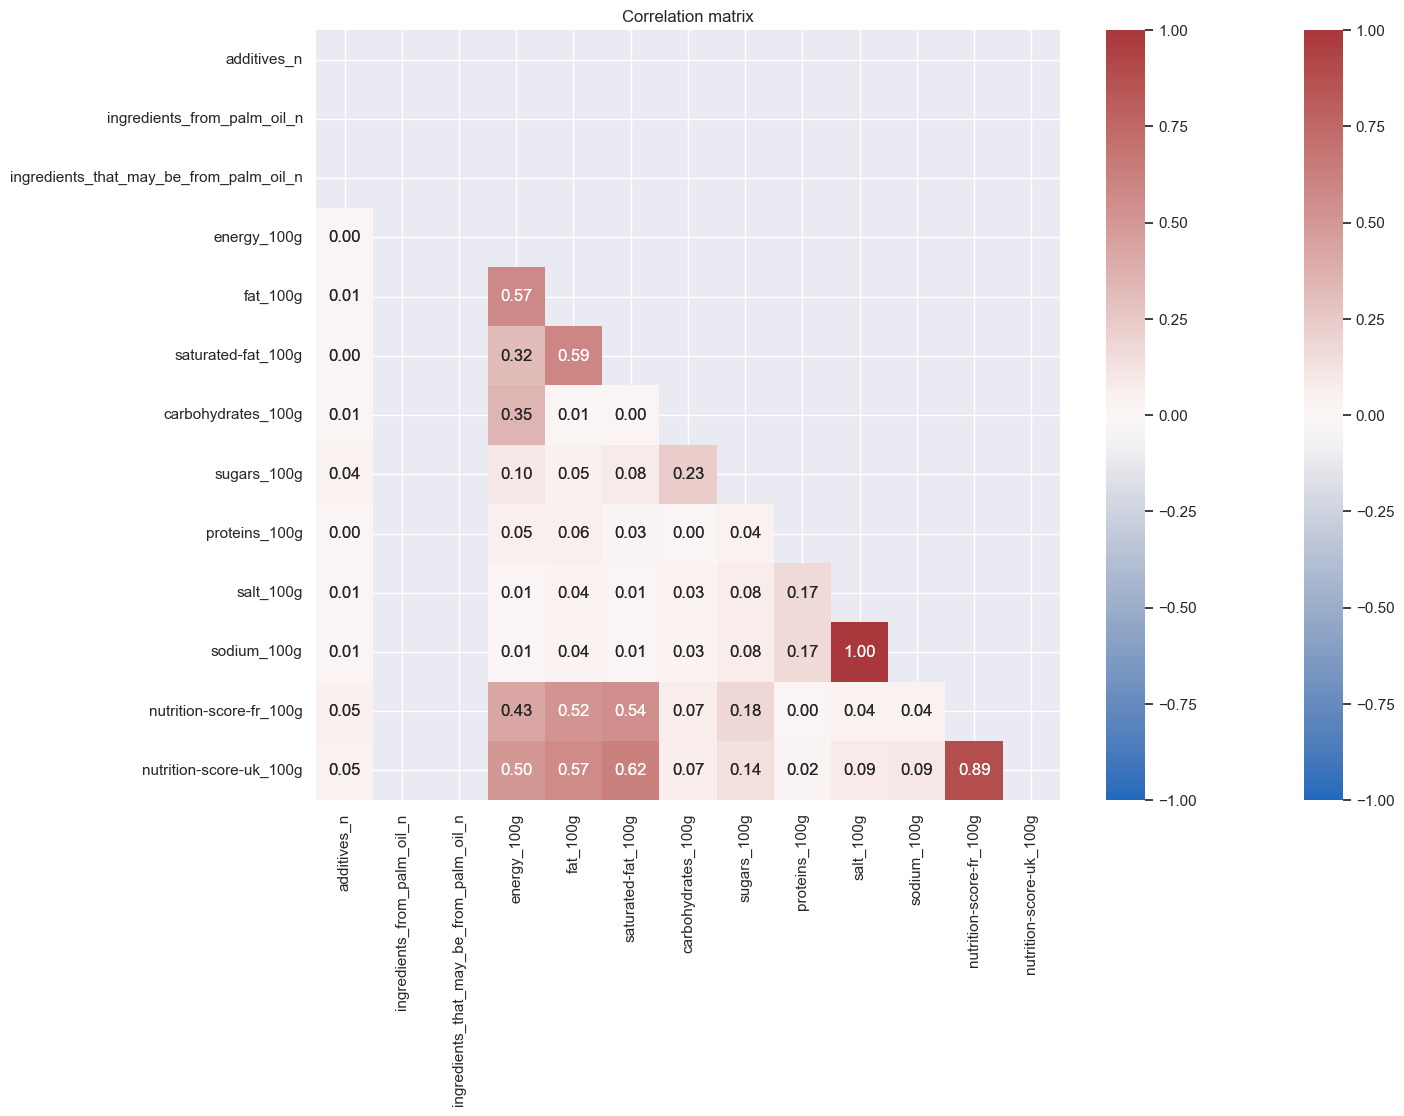

In [7]:
filtered_data = drop_highly_correlated_features(filtered_data, 0.85)

### Characterizing the type of missing data (MCAR, MAR, MNAR)

<Axes: >

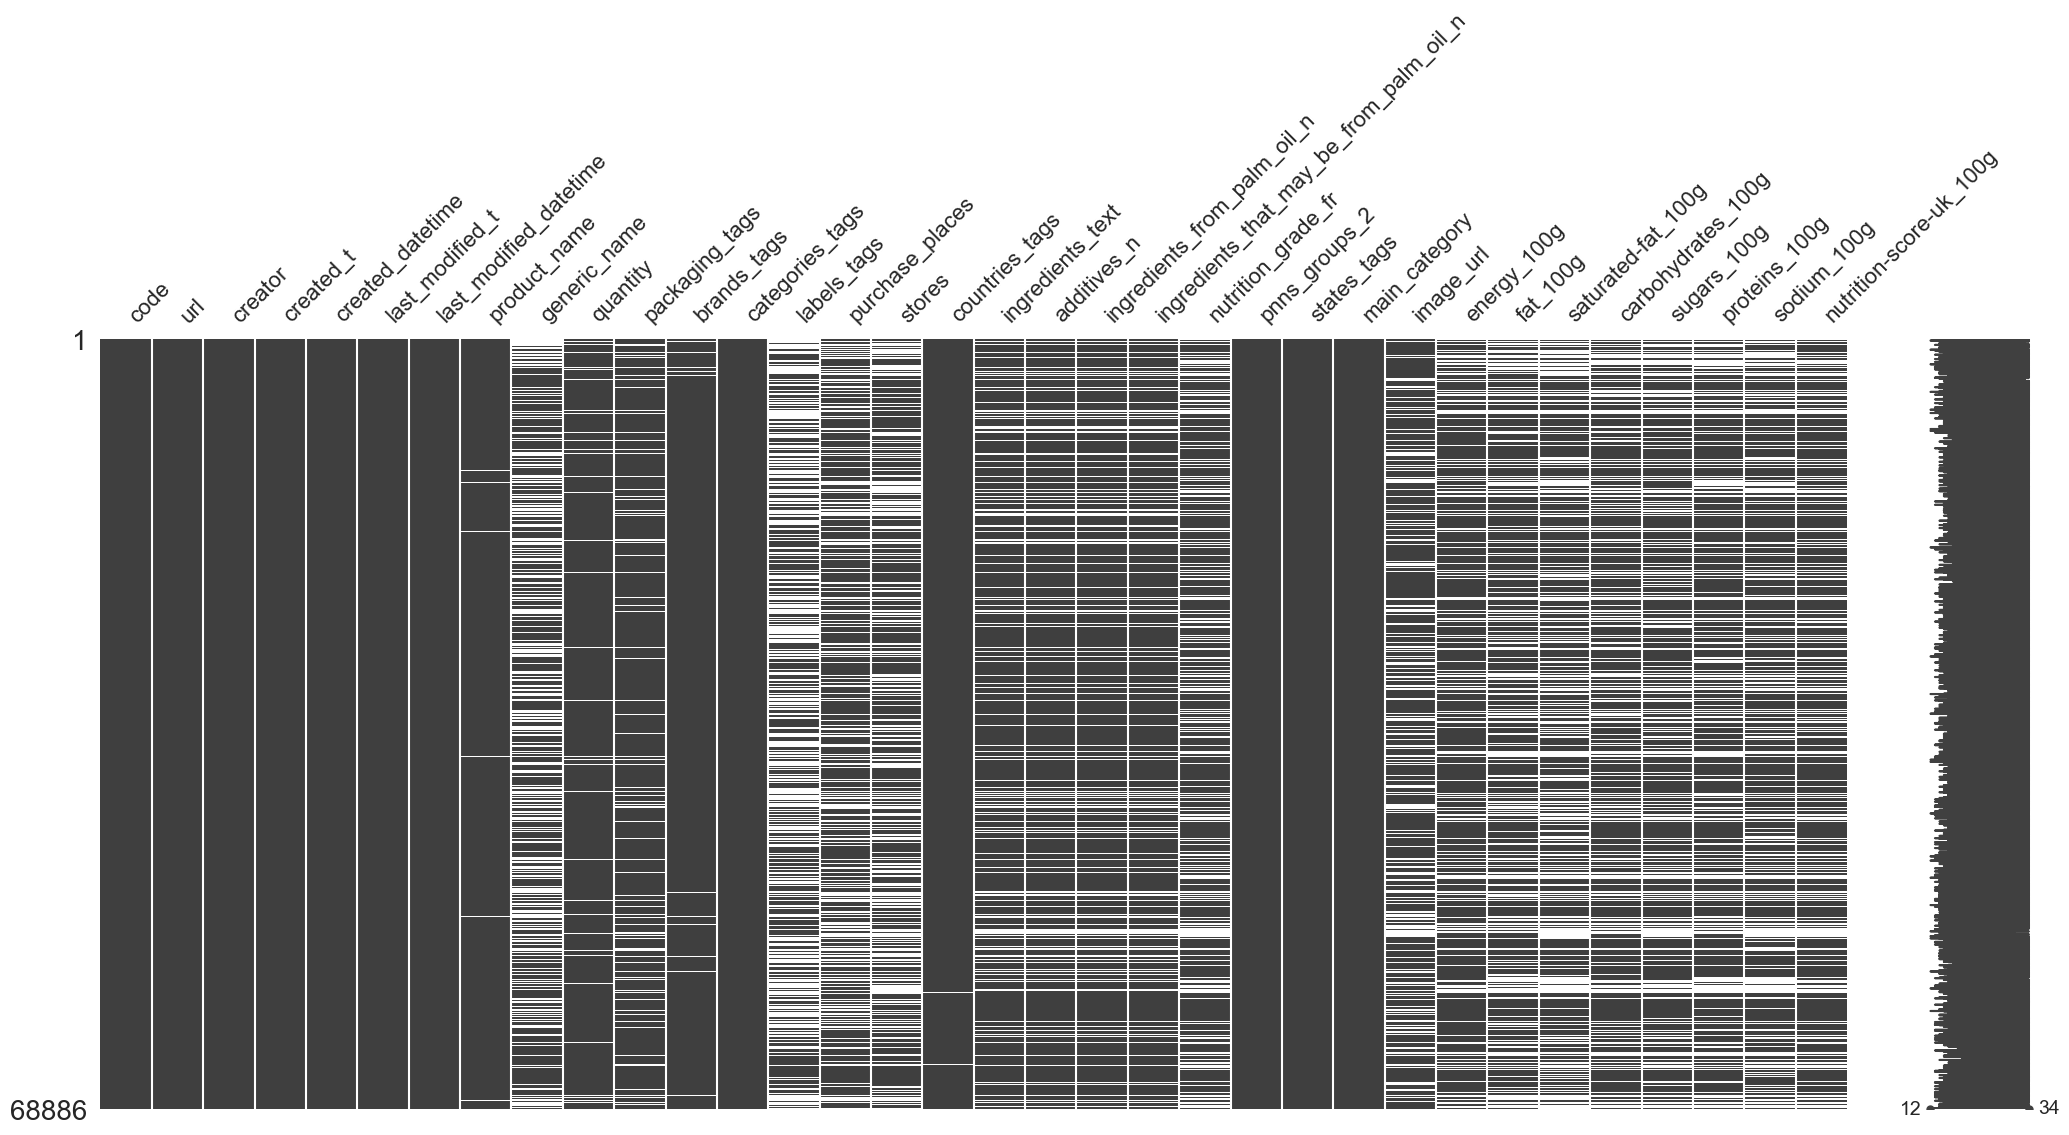

In [8]:
msno.matrix(df=filtered_data)

<Axes: >

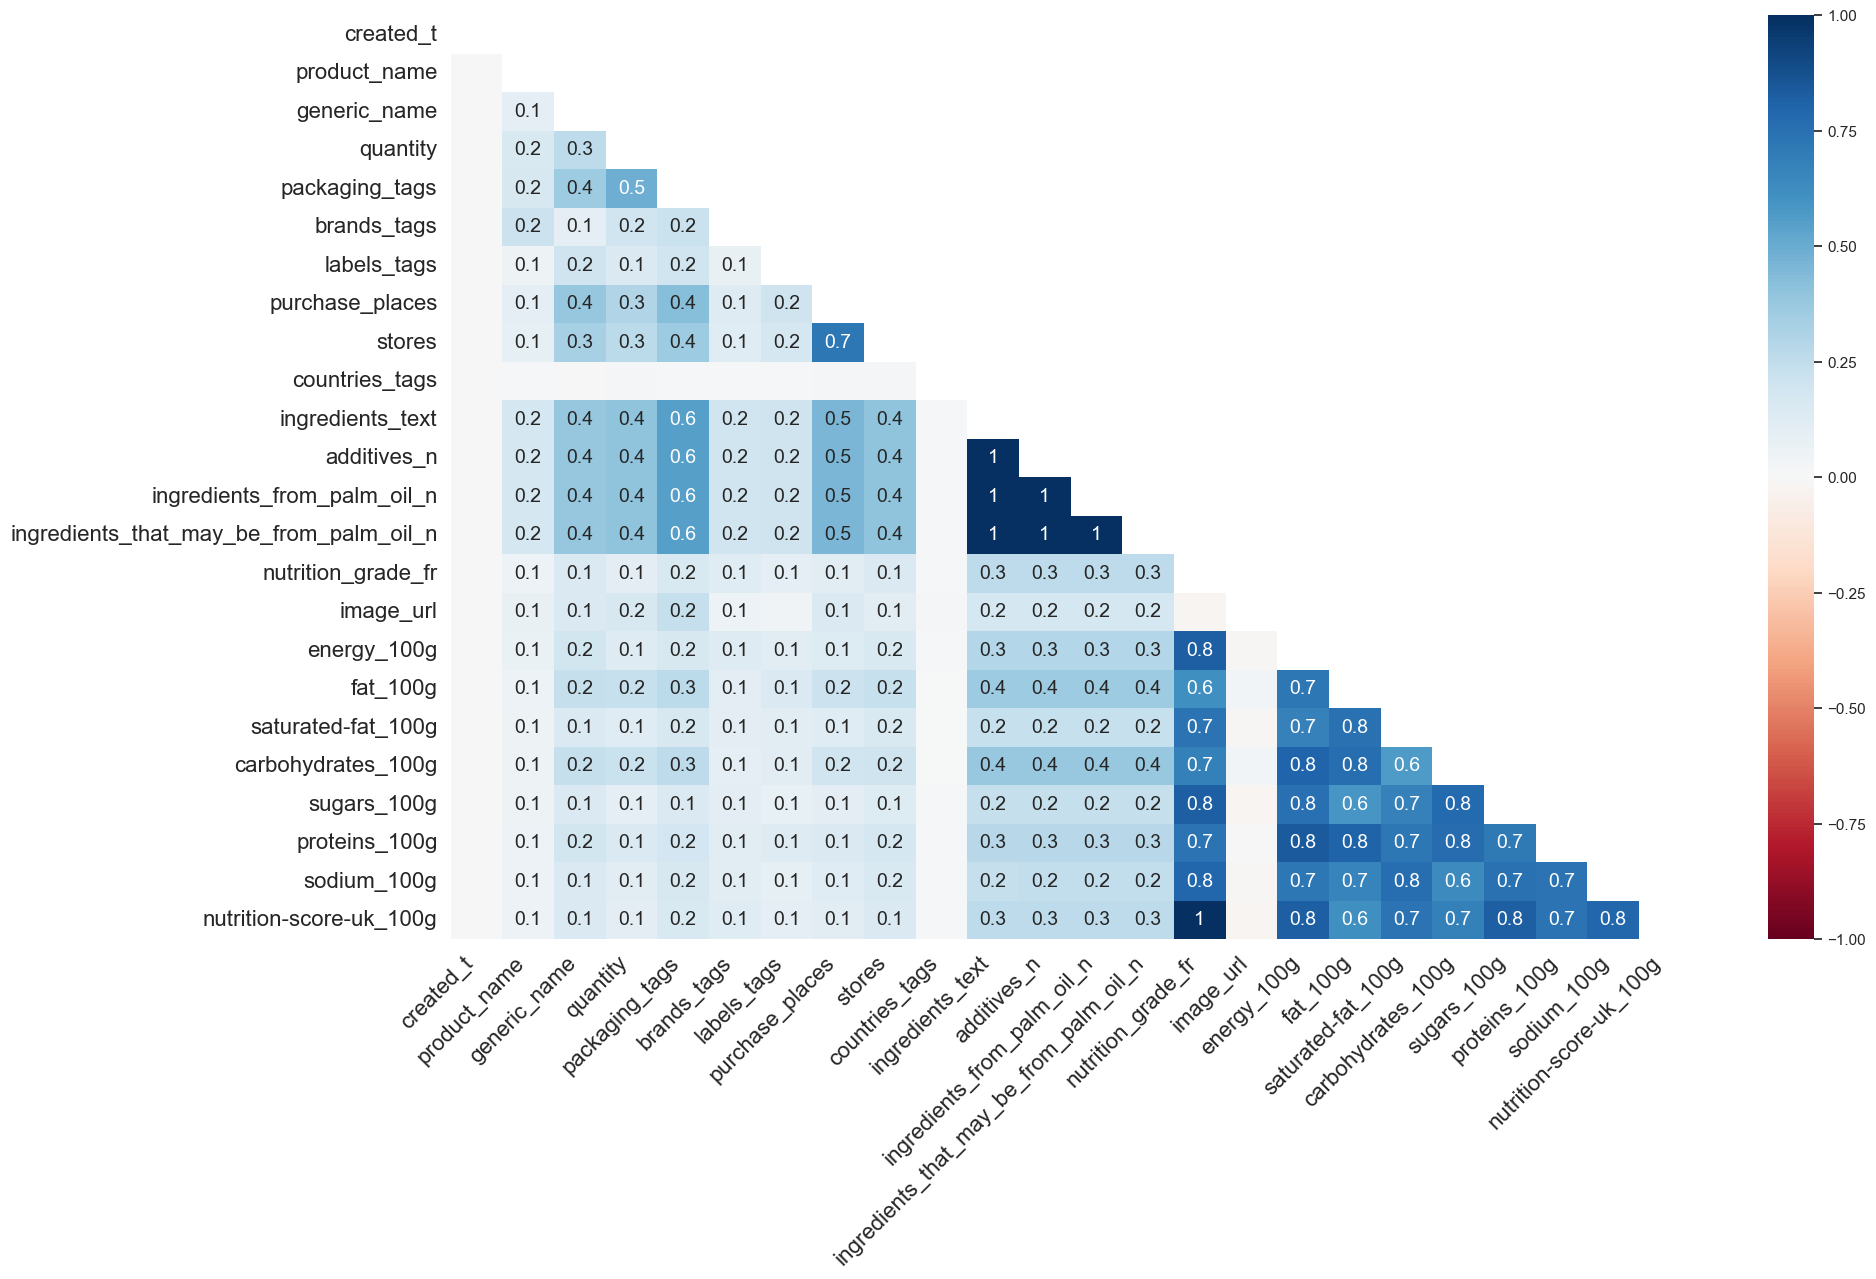

In [9]:
msno.heatmap(df=filtered_data)

<Axes: >

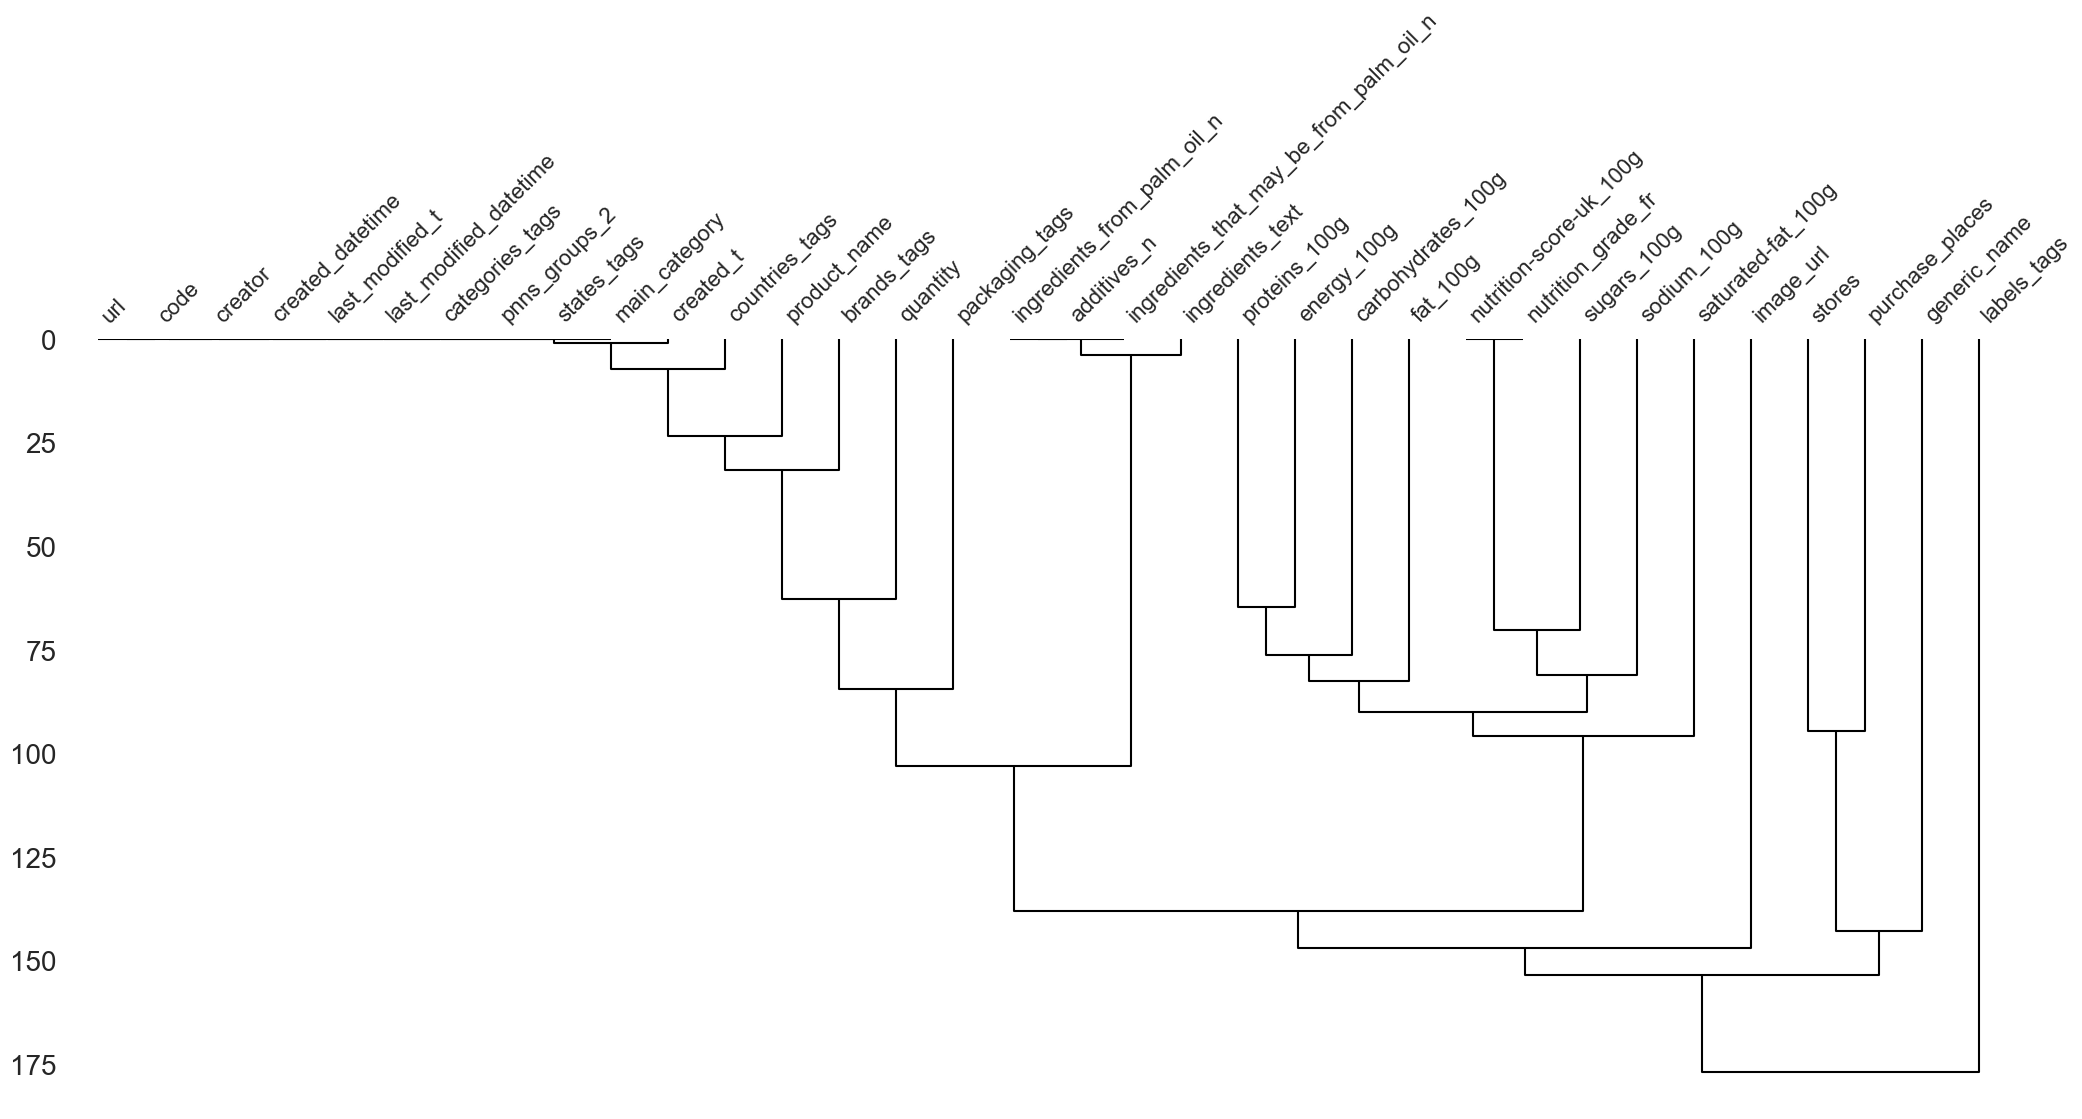

In [10]:
msno.dendrogram(df=filtered_data)

In [8]:
def visualize_smth(df:pd.DataFrame, x:str="event_date", y=None, date_format:str='%Y%m%d', suptitle:str="Title", method:Callable=sns.displot, subplot_params:dict={}, **plot_params):
    data = df.copy()
    x_is_date = False
    if "row" in plot_params:
        # Define the maximum number of rows
        max_rows = 10
        # Create a subset of the data based on the maximum number of rows
        unique_rows = df[plot_params["row"]].unique()[:max_rows]
        # Filter the dataset
        data = df[df[plot_params["row"]].isin(unique_rows)]
    try:
        # Convert event_date from string to datetime
        data[x] = pd.to_datetime(data[x], format=date_format, errors='raise')
        x_is_date = True
    except Exception:
        print("Data on X axis will not be considered as a date.")
    finally:
        data = data.sort_values(by=x)
        data = data.reset_index(drop=True)
    locator = mdates.AutoDateLocator()
    # locator.intervald["MONTHLY"] = [1]
    # from the all_dates DataFrame, left join onto the DataFrame with missing dates
    # all_dates_df = pd.DataFrame(pd.date_range(data[x_date].min(), data[x_date].max()), columns=[x_date])
    # completed_data = all_dates_df.merge(right=data, how='left', on=x_date)
    def wrapper(locator, **params):
        ax = plt.gca()
        # method(x=x_date, y=y, ax=ax, **subplot_params)
        ax.tick_params(axis='x', labelrotation=90, labelbottom=True)
        # for i in range(len(ax.containers)):
        #     ax.bar_label(ax.containers[i], fmt=lambda x: int(x) if int(x) > 0 else '', padding=2, fontsize="12")
        if x_is_date:
            ax.xaxis.set_major_locator(locator)
    method_type = type(method())
    plt.close()
    if method_type == sns.axisgrid.FacetGrid:
        g = method(data=data, x=x, y=y, **plot_params, **subplot_params)
    else:
        g = sns.FacetGrid(data=data, **plot_params)
        g.map_dataframe(func=method, x=x, y=y, **subplot_params)
    g.map_dataframe(func=wrapper, locator=locator)
    g.figure.suptitle(suptitle, y=1)
    #g.ax.legend(loc=2)
    g.add_legend()
    g.tight_layout()
    plt.show()

In [137]:
def edit_distance_unordered(list1, list2):
    """Calculate distance between 2 unordered lists based on the number of insertions and deletions."""
    try:
        set1, set2 = set(list1), set(list2)
    except:
        print(f"x: {list1}, {isinstance(list1, (int, float))} // y: {list2}, {isinstance(list2, (int, float))} // {not (isinstance(list1, (int, float)) or isinstance(list2, (int, float)))}")
    deletions = len(set1 - set2)  # Elements in list1 but not in list2
    insertions = len(set2 - set1)  # Elements in list2 but not in list1
    return (deletions + insertions) / (len(set1) + len(set2))

In [157]:
# def handle_nan_and_numeric(x, y):

#     if pd.isna([x,y]).any():
#         return 0
#     else:
#         return x - y

# def custom_metric(x_missing, y_potential_neighbor):
#     assert len(x_missing) == len(y_potential_neighbor)
#     difference = [edit_distance_unordered(x, y) if not (isinstance(x, (int, float)) or isinstance(y, (int, float))) else handle_nan_and_numeric(x, y) for x, y in zip(x_missing, y_potential_neighbor)]
#     distance = np.linalg.norm(difference) # computes the sum of squares, then square root

#     return distance

In [213]:
def handle_nan_and_numeric(x, y):
    """Handle NaN and numeric differences efficiently."""
    if pd.isna(x) or pd.isna(y):
        return 0
    print(x, y)
    return x - y

def custom_metric(x_missing, y_potential_neighbor):
    """Compute the custom metric efficiently."""
    # Convert to NumPy arrays for efficient processing
    x_missing = np.array(x_missing, dtype=object)
    y_potential_neighbor = np.array(y_potential_neighbor, dtype=object)
    
    # Preprocess numeric and non-numeric elements
    numeric_mask = np.vectorize(lambda x, y: isinstance(x, (int, float)) and isinstance(y, (int, float)))(x_missing, y_potential_neighbor)
    
    # Numeric difference handling
    numeric_diff = np.where(
        numeric_mask,
        np.vectorize(handle_nan_and_numeric)(x_missing, y_potential_neighbor),
        0  # Default value for non-numeric pairs
    )
    
    # Non-numeric difference handling
    non_numeric_diff = np.where(
        ~numeric_mask,
        np.vectorize(lambda x, y: edit_distance_unordered(x, y))(x_missing, y_potential_neighbor),
        0  # Default value for numeric pairs
    )
    
    # Combine numeric and non-numeric differences
    difference = numeric_diff + non_numeric_diff
    
    # Compute the distance
    distance = np.linalg.norm(difference)
    return distance

In [64]:
custom_metric(np.array([np.nan, 5, np.nan]), np.array([1,1,1]))

np.float64(4.0)

In [205]:
def imputation(df:pd.DataFrame, features_to_estimate:list[str], group_columns:list[str]):
    '''
    Imputes missing values for specified features in a DataFrame using group averages or a specified method.

    Parameters:
    df (pd.DataFrame): Original DataFrame.
    features_to_estimate (str): Features for which missing data needs to be imputed.
    group_columns (str): Possible grouping variables for aggregation. All combinations will be attempted and the one with the lowest variation will be chosen for each missing value.
    method (Callable): Imputation method (e.g., mean, median). Defaults to np.mean.

    Returns:
    pd.DataFrame: DataFrame with imputed values for the specified indicator.
    '''
    if not set(group_columns).issubset(df.columns):
        raise ValueError("Argument 'group_columns' should only contain valid 'df' columns")
    
    df_copy = df.copy()

    from sklearn.preprocessing import MinMaxScaler

    numeric_columns = df_copy.select_dtypes(include=np.number).columns

    # Scale between 0 and 1
    scaler = MinMaxScaler()
    df_copy[numeric_columns] = pd.DataFrame(scaler.fit_transform(df_copy[numeric_columns]), columns=numeric_columns)
    
    # Transform columns with list-like values with split
    #string_columns = df_copy.select_dtypes(include='object')
    #for col in string_columns:
    #    df_copy[col] = np.char.split(string_columns[col].values.astype(str), sep=',').tolist()

    #missing_data = df_copy.loc[df_copy[features_to_estimate].isna().any(axis=1)]

    distance = squareform(pdist(df_copy, metric=custom_metric))
    
    neigh = NearestNeighbors(n_neighbors=5, metric="precomputed")

    neigh.fit(distance)

    nbrs = neigh.kneighbors(n_neighbors=5, return_distance=False)
    

    return nbrs

In [214]:
truncated_df = filtered_data[:100]
pd.DataFrame(imputation(df=truncated_df, features_to_estimate=filtered_data.columns[filtered_data.isna().any()], group_columns=filtered_data.columns))

b7 b7


TypeError: unsupported operand type(s) for -: 'str' and 'str'

In [206]:
cProfile.run('pd.DataFrame(imputation(df=truncated_df, features_to_estimate=filtered_data.columns[filtered_data.isna().any()], group_columns=filtered_data.columns))', sort="cumtime")

         3237463 function calls (3237083 primitive calls) in 2.149 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    2.149    2.149 {built-in method builtins.exec}
        1    0.000    0.000    2.149    2.149 <string>:1(<module>)
        1    0.000    0.000    2.111    2.111 2596866525.py:1(imputation)
        1    0.000    0.000    2.096    2.096 distance.py:1864(pdist)
        1    0.011    0.011    2.096    2.096 distance.py:2627(_pdist_callable)
     4950    0.018    0.000    2.085    0.000 2957936690.py:8(custom_metric)
     4950    0.164    0.000    2.015    0.000 2957936690.py:10(<listcomp>)
    79196    0.078    0.000    1.577    0.000 2957936690.py:1(handle_nan_and_numeric)
    79220    0.037    0.000    1.268    0.000 missing.py:101(isna)
    79220    0.221    0.000    1.231    0.000 missing.py:184(_isna)
913336/913333    0.249    0.000    0.594    0.000 {built-in method builtins.is

In [12]:
import numpy as np

from sklearn.datasets import fetch_california_housing, load_diabetes

rng = np.random.RandomState(42)

X_diabetes, y_diabetes = load_diabetes(return_X_y=True)
X_california, y_california = fetch_california_housing(return_X_y=True)
X_california = X_california[:300]
y_california = y_california[:300]
X_diabetes = X_diabetes[:300]
y_diabetes = y_diabetes[:300]


def add_missing_values(X_full, y_full):
    n_samples, n_features = X_full.shape

    # Add missing values in 75% of the lines
    missing_rate = 0.75
    n_missing_samples = int(n_samples * missing_rate)

    missing_samples = np.zeros(n_samples, dtype=bool)
    missing_samples[:n_missing_samples] = True

    rng.shuffle(missing_samples)
    missing_features = rng.randint(0, n_features, n_missing_samples)
    X_missing = X_full.copy()
    X_missing[missing_samples, missing_features] = np.nan
    y_missing = y_full.copy()

    return X_missing, y_missing


X_miss_california, y_miss_california = add_missing_values(X_california, y_california)

In [13]:
rng = np.random.RandomState(0)

from sklearn.ensemble import RandomForestRegressor

# To use the experimental IterativeImputer, we need to explicitly ask for it:
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

N_SPLITS = 4
regressor = RandomForestRegressor(random_state=0)

In [14]:
def get_scores_for_imputer(imputer, X_missing, y_missing):
    estimator = make_pipeline(imputer, regressor)
    impute_scores = cross_val_score(
        estimator, X_missing, y_missing, scoring="neg_mean_squared_error", cv=N_SPLITS
    )
    return impute_scores


x_labels = []

mses_california = np.zeros(5)
stds_california = np.zeros(5)
mses_diabetes = np.zeros(5)
stds_diabetes = np.zeros(5)

In [15]:
def get_full_score(X_full, y_full):
    full_scores = cross_val_score(
        regressor, X_full, y_full, scoring="neg_mean_squared_error", cv=N_SPLITS
    )
    return full_scores.mean(), full_scores.std()


mses_california[0], stds_california[0] = get_full_score(X_california, y_california)
mses_diabetes[0], stds_diabetes[0] = get_full_score(X_diabetes, y_diabetes)
x_labels.append("Full data")

In [16]:
def get_impute_zero_score(X_missing, y_missing):
    imputer = SimpleImputer(
        missing_values=np.nan, add_indicator=True, strategy="constant", fill_value=0
    )
    zero_impute_scores = get_scores_for_imputer(imputer, X_missing, y_missing)
    return zero_impute_scores.mean(), zero_impute_scores.std()


mses_california[1], stds_california[1] = get_impute_zero_score(
    X_miss_california, y_miss_california
)
mses_diabetes[1], stds_diabetes[1] = get_impute_zero_score(
    X_miss_diabetes, y_miss_diabetes
)
x_labels.append("Zero imputation")

### Using K-Nearest Neighbors

In [9]:
filtered_data.to_csv("filtered_data_test.csv")

In [2]:
filtered_data = pd.read_csv("filtered_data_test.csv")

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_3460\2334537578.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  filtered_data = pd.read_csv("filtered_data_test.csv")


In [23]:
always_irrelevant_columns = ["last_modified_datetime", "creator", "url", "last_modified_t", "created_datetime", "created_t", "image_url", "Unnamed: 0", "quantity", "code", "product_name"]
filtered_data.drop(columns=always_irrelevant_columns, inplace=True)

In [24]:
columns_to_convert = filtered_data.select_dtypes(include=object).columns
filtered_data[columns_to_convert] = filtered_data[columns_to_convert].astype(str)

In [29]:
filtered_data.select_dtypes(include=object).columns

Index(['generic_name', 'packaging_tags', 'brands_tags', 'categories_tags',
       'labels_tags', 'purchase_places', 'stores', 'countries_tags',
       'ingredients_text', 'nutrition_grade_fr', 'pnns_groups_2',
       'states_tags', 'main_category'],
      dtype='object')

In [45]:
columns_to_convert = ["main_category", "pnns_groups_2"]

In [47]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

columnTransformer = ColumnTransformer([('encoder', OneHotEncoder(drop="first"), columns_to_convert)], remainder='passthrough')
dataset = columnTransformer.fit_transform(filtered_data[columns_to_convert])

In [48]:
dataset = pd.DataFrame.sparse.from_spmatrix(dataset)

In [49]:
dataset

,0,1,2,3,4,5,6,7,8,9,...,160,161,162,163,164,165,166,167,168,169
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1.0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68881,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
68882,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
68883,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
68884,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
all_data = []

In [53]:
dropped = filtered_data.drop(columns=columns_to_convert)
dropped = dropped.select_dtypes(include=np.number)

In [54]:
concat = pd.concat([dropped, dataset], axis=1)

In [56]:
concat

,additives_n,ingredients_from_palm_oil_n,ingredients_that_may_be_from_palm_oil_n,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,sodium_100g,...,160,161,162,163,164,165,166,167,168,169
0,0.0,0.0,0.0,1210.0,12.0,7.0,23.0,NaN,22.00,0.850,...,0,0,0,1.0,0,0,0,0,0,0
1,10.0,0.0,1.0,1520.0,14.4,NaN,54.1,28.1,4.79,0.363,...,0,0,0,0,0,0,0,0,0,0
2,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
3,5.0,0.0,0.0,1090.0,10.7,2.0,38.7,24.7,3.33,0.255,...,0,0,0,0,0,0,0,0,0,0
4,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68881,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
68882,0.0,0.0,0.0,21.0,0.2,0.2,0.5,0.5,0.50,0.010,...,0,0,0,0,0,0,0,0,0,0
68883,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
68884,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0


In [58]:
concat.columns = concat.columns.astype(str)

In [59]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df = pd.DataFrame(scaler.fit_transform(concat), columns=concat.columns)

c:\Users\Utilisateur\Documents\GitHub\DS_3\.venv\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\Utilisateur\Documents\GitHub\DS_3\.venv\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


In [60]:
df

,additives_n,ingredients_from_palm_oil_n,ingredients_that_may_be_from_palm_oil_n,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,sodium_100g,...,160,161,162,163,164,165,166,167,168,169
0,0.000000,0.0,0.0,0.055000,0.120111,0.070706,0.230107,NaN,0.255813,0.010241,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.322581,0.0,0.2,0.069091,0.144136,NaN,0.541266,0.281140,0.055697,0.004373,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.161290,0.0,0.0,0.049545,0.107098,0.020201,0.387187,0.247123,0.038720,0.003072,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68881,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
68882,0.000000,0.0,0.0,0.000955,0.001992,0.002019,0.004993,0.005002,0.005813,0.000120,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
68883,0.000000,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
68884,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
def get_impute_knn_score(X_missing, y_missing):
    imputer = KNNImputer(missing_values=np.nan, add_indicator=True)
    knn_impute_scores = get_scores_for_imputer(imputer, X_missing, y_missing)
    return knn_impute_scores.mean(), knn_impute_scores.std()


mses_california[2], stds_california[2] = get_impute_knn_score(
    X_miss_california, y_miss_california
)
mses_diabetes[2], stds_diabetes[2] = get_impute_knn_score(
    X_miss_diabetes, y_miss_diabetes
)
x_labels.append("KNN Imputation")

In [61]:
import numpy as np
from sklearn.impute import KNNImputer

X = df
imputer = KNNImputer(n_neighbors=5)
results = imputer.fit_transform(X)

In [63]:
pd.DataFrame(results)

,0,1,2,3,4,5,6,7,8,9,...,171,172,173,174,175,176,177,178,179,180
0,0.000000,0.0,0.00,0.055000,0.120111,0.070706,0.230107,0.096747,0.255813,0.010241,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.322581,0.0,0.20,0.069091,0.144136,0.061494,0.541266,0.281140,0.055697,0.004373,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.0,0.00,0.072936,0.040030,0.004847,0.674934,0.020009,0.123720,0.008111,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.161290,0.0,0.00,0.049545,0.107098,0.020201,0.387187,0.247123,0.038720,0.003072,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.0,0.00,0.037100,0.019810,0.002363,0.242514,0.033216,0.161394,0.000360,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68881,0.000000,0.0,0.00,0.038073,0.003393,0.002827,0.208897,0.186512,0.009534,0.000228,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
68882,0.000000,0.0,0.00,0.000955,0.001992,0.002019,0.004993,0.005002,0.005813,0.000120,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
68883,0.000000,0.0,0.00,0.069191,0.344338,0.113736,0.032206,0.008003,0.132092,0.006517,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
68884,0.006452,0.2,0.00,0.124382,0.406000,0.088545,0.282134,0.095447,0.208836,0.005637,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [47]:

X = filtered_data.select_dtypes(include=np.number)
imputer = KNNImputer(n_neighbors=2)
imputer.fit_transform(X)

array([[ 0.        ,  0.        ,  0.        , ..., 22.        ,
         0.85      ,  6.        ],
       [10.        ,  0.        ,  1.        , ...,  4.79      ,
         0.363     ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ..., 12.7       ,
         0.46437008, 12.        ],
       ...,
       [ 0.        ,  0.        ,  0.        , ..., 12.7       ,
         0.46437008, 12.        ],
       [ 1.75967008,  0.05690523,  0.13111891, ...,  7.99206939,
         0.37629808,  7.87506671],
       [ 1.75967008,  0.05690523,  0.13111891, ...,  7.99206939,
         0.37629808,  7.87506671]])

### Using mean

In [10]:
def get_impute_mean(X_missing, y_missing):
    imputer = SimpleImputer(missing_values=np.nan, strategy="mean", add_indicator=True)
    mean_impute_scores = get_scores_for_imputer(imputer, X_missing, y_missing)
    return mean_impute_scores.mean(), mean_impute_scores.std()


mses_california[3], stds_california[3] = get_impute_mean(
    X_miss_california, y_miss_california
)
mses_diabetes[3], stds_diabetes[3] = get_impute_mean(X_miss_diabetes, y_miss_diabetes)
x_labels.append("Mean Imputation")

### Using iterative imputation

In [35]:
KNNImputer(missing_values=np.nan, add_indicator=True).__getstate__()

{'missing_values': nan,
 'add_indicator': True,
 'keep_empty_features': False,
 'n_neighbors': 5,
 'weights': 'uniform',
 'metric': 'nan_euclidean',
 'copy': True,
 '_sklearn_version': '1.5.2'}

In [44]:
def get_impute_score(imputer, X_missing, y_missing):
    impute_scores = get_scores_for_imputer(imputer, X_missing, y_missing)
    return impute_scores.mean(), impute_scores.std()

In [ ]:
imputers = {
    "Median Imputation":SimpleImputer(
        missing_values=np.nan, 
        strategy="median", 
        add_indicator=True
    ),
    "Zero Imputation":SimpleImputer(
        missing_values=np.nan, 
        add_indicator=True, 
        strategy="constant", 
        fill_value=0
    ),
    "KNN Imputation":KNNImputer(
        missing_values=np.nan, 
        add_indicator=True
    ),
    "Iterative Imputation":IterativeImputer(
        missing_values=np.nan,
        add_indicator=True,
        random_state=0,
        n_nearest_features=3,
        max_iter=1,
        sample_posterior=True,
    )
}

for imputer in imputers:
    get_impute_score(imputer, X_missing, y_missing)

In [11]:
def get_impute_iterative(X_missing, y_missing):
    imputer = IterativeImputer(
        missing_values=np.nan,
        add_indicator=True,
        random_state=0,
        n_nearest_features=3,
        max_iter=1,
        sample_posterior=True,
    )
    iterative_impute_scores = get_scores_for_imputer(imputer, X_missing, y_missing)
    return iterative_impute_scores.mean(), iterative_impute_scores.std()


mses_california[4], stds_california[4] = get_impute_iterative(
    X_miss_california, y_miss_california
)
mses_diabetes[4], stds_diabetes[4] = get_impute_iterative(
    X_miss_diabetes, y_miss_diabetes
)
x_labels.append("Iterative Imputation")

mses_diabetes = mses_diabetes * -1
mses_california = mses_california * -1

### Plot results

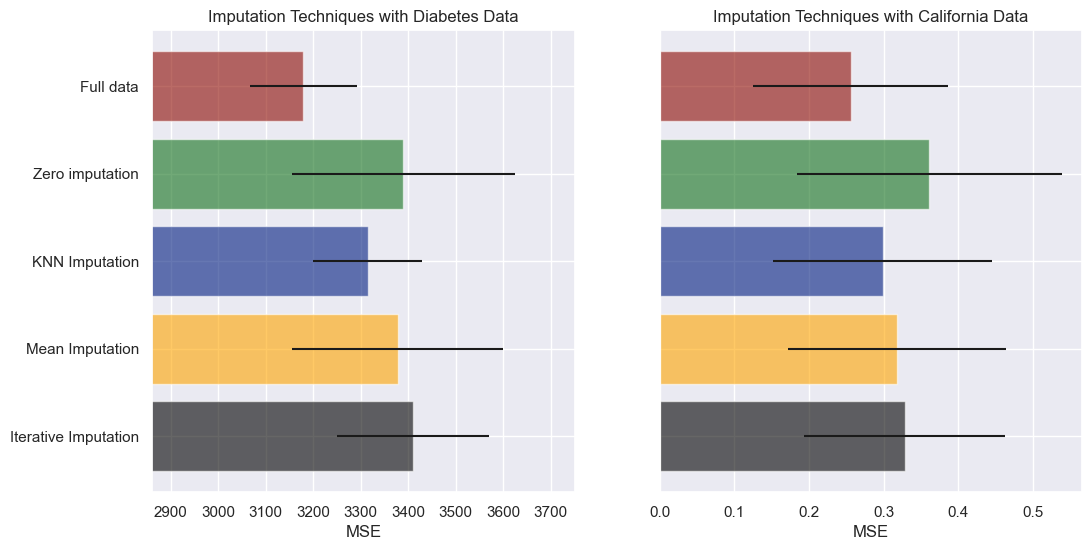

In [13]:
import matplotlib.pyplot as plt

n_bars = len(mses_diabetes)
xval = np.arange(n_bars)

colors = ["r", "g", "b", "orange", "black"]

# plot diabetes results
plt.figure(figsize=(12, 6))
ax1 = plt.subplot(121)
for j in xval:
    ax1.barh(
        j,
        mses_diabetes[j],
        xerr=stds_diabetes[j],
        color=colors[j],
        alpha=0.6,
        align="center",
    )

ax1.set_title("Imputation Techniques with Diabetes Data")
ax1.set_xlim(left=np.min(mses_diabetes) * 0.9, right=np.max(mses_diabetes) * 1.1)
ax1.set_yticks(xval)
ax1.set_xlabel("MSE")
ax1.invert_yaxis()
ax1.set_yticklabels(x_labels)

# plot california dataset results
ax2 = plt.subplot(122)
for j in xval:
    ax2.barh(
        j,
        mses_california[j],
        xerr=stds_california[j],
        color=colors[j],
        alpha=0.6,
        align="center",
    )

ax2.set_title("Imputation Techniques with California Data")
ax2.set_yticks(xval)
ax2.set_xlabel("MSE")
ax2.invert_yaxis()
ax2.set_yticklabels([""] * n_bars)

plt.show()

In [ ]:
mses_california

In [ ]:
visualize_smth(df=mses_california, )

### Using Multiple Imputation 

In [122]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Use IterativeImputer for multivariate imputation
imputer = IterativeImputer(random_state=0)
data_imputed = imputer.fit_transform(filtered_data.select_dtypes(include=np.number))

# Convert back to DataFrame
data = pd.DataFrame(data_imputed, columns=filtered_data.select_dtypes(include=np.number).columns)

c:\Users\Utilisateur\Documents\GitHub\DS_3\.venv\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Use IterativeImputer for multivariate imputation
imputer = IterativeImputer(random_state=0)
data_imputed = imputer.fit_transform(filtered_data.select_dtypes(include=np.number))

# Convert back to DataFrame
data = pd.DataFrame(data_imputed, columns=filtered_data.select_dtypes(include=np.number).columns)

In [38]:
def coef_var(values:pd.Series):
    values = values.dropna()
    if (len(values) > 20):
        mean = np.mean(values)
        if mean == 0:
            return 0
        cv = np.std(values)/abs(mean)
        if (cv < 0.3):
            return cv
    return np.nan

def method_if_criteria_met(values:pd.Series, method:Callable):
    values = values.dropna()
    if (len(values) > 20):
        mean = np.mean(values)
        if mean == 0:
            return 0
        if (np.std(values)/abs(mean) < 0.3):
            return method(values)
    return np.nan

In [39]:
def imputation(df:pd.DataFrame, features_to_estimate:list[str], group_columns:list[str], method:Callable=np.mean):
    '''
    Imputes missing values for specified features in a DataFrame using group averages or a specified method.

    Parameters:
    df (pd.DataFrame): Original DataFrame.
    features_to_estimate (str): Features for which missing data needs to be imputed.
    group_columns (str): Possible grouping variables for aggregation. All combinations will be attempted and the one with the lowest variation will be chosen for each missing value.
    method (Callable): Imputation method (e.g., mean, median). Defaults to np.mean.

    Returns:
    pd.DataFrame: DataFrame with imputed values for the specified indicator.
    '''
    if not set(group_columns).issubset(df.columns):
        raise ValueError("Argument 'group_columns' should only contain valid 'df' columns")
    
    df_copy = df.copy()

    df_copy.loc[:, "group_id_set"] = df_copy.loc[:, group_columns].fillna('nan').apply(set, axis=1)

    missing_data = df_copy.loc[df_copy[features_to_estimate].isna().any(axis=1)]

    filtered_df = df_copy.loc[df_copy["group_id_set"].isin()]
    

    missing_data.loc[:, "group_id_set"] = missing_data.loc[:, group_columns].fillna('nan').apply(set, axis=1)

    df_cvs_medians = pd.DataFrame()

    # Partial function for method_if_criteria_met
    method_func = partial(method_if_criteria_met, method=method)

    for i in range(1, len(group_columns) + 1):
        for combo in combinations(group_columns, i):
            print(f'''Processing combination: "{'", "'.join(list(combo))}"''')
            df_copy["group_id"] = df_copy[list(combo)].fillna('nan').agg("_|_".join, axis=1)

            # Group by current combination and apply the function
            group = df_copy[["group_id"] + features_to_estimate].groupby("group_id").agg([coef_var, method_func])

            if df_cvs_medians.empty:
                df_cvs_medians = group
            else:
                df_cvs_medians = pd.concat([df_cvs_medians, group])

    df_cvs_medians = df_cvs_medians.dropna(how="all")

    for i in missing_data.index:
        group_id_set = missing_data.loc[i, "group_id_set"]
        matching_rows = df_cvs_medians.loc[df_cvs_medians.index.map(lambda x: set(x.split("_|_")).issubset(group_id_set))]

        missing_features = missing_data[features_to_estimate].loc[i].isna().index
        
        for feature in missing_features:
            sub_df = matching_rows[feature]
            values = sub_df.loc[sub_df["coef_var"] == sub_df["coef_var"].min(), "method_if_criteria_met"].values
            if len(values) > 0:
                df_copy.loc[i, feature] = values[0]

    return df_copy

In [65]:
group_columns=["categories_tags", "countries_tags", "pnns_groups_2"]
features_to_estimate = ["sugars_100g", "fat_100g"]
# test = filtered_data.loc[filtered_data["countries_tags"] == "France", features_to_estimate].copy()
# cProfile.run('imputation(df=filtered_data, group_columns=group_columns, features_to_estimate=features_to_estimate)', sort="cumtime")

In [66]:
df_copy = filtered_data.copy()

df_copy.loc[:, "group_id_set"] = df_copy.loc[:, group_columns].fillna('nan').apply(set, axis=1)

missing_data = df_copy.loc[df_copy[features_to_estimate].isna().any(axis=1)]

filtered_df = df_copy.loc[df_copy["group_id_set"].isin(missing_data["group_id_set"])]

filtered_df

,generic_name,packaging_tags,brands_tags,categories_tags,labels_tags,purchase_places,stores,countries_tags,ingredients_text,additives_n,...,main_category,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,sodium_100g,nutrition-score-uk_100g,group_id_set
0,Laitue en salade,frais,kirkland-signature,"en:plant-based-foods-and-beverages,en:plant-ba...",nan,nan,Costco,Canada,INGREDIENTS : LAITUE. VINAIGRETTE (HUILE DE CA...,0.0,...,en:fresh-vegetables,1210.0,12.0,7.0,23.0,NaN,22.0,0.850,6.0,"{Canada, en:plant-based-foods-and-beverages,en..."
2,Flute,"paper,plastic-film",waitrose,"en:plant-based-foods-and-beverages,en:plant-ba...",nan,"Brent,UK",Waitrose,United Kingdom,Wheat,0.0,...,en:breads,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{Bread, United Kingdom, en:plant-based-foods-a..."
4,nan,sachet-plastique,bertrand-lejeune,"en:plant-based-foods-and-beverages,en:plant-ba...","en:organic,en:eu-organic,fr:ab-agriculture-bio...",nan,nan,France,lentilles vertes,0.0,...,en:plant-based-foods-and-beverages,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{en:plant-based-foods-and-beverages,en:plant-b..."
5,Biscuits sablés déclassés fourrage au cacao,"carton,boite",st-michel,"en:sugary-snacks,en:biscuits-and-cakes,en:bisc...",en:green-dot,France,nan,France,"Sucre, farine de _Blé_, graisse et huiles végé...",3.0,...,fr:sables,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{France, en:sugary-snacks,en:biscuits-and-cake..."
7,Pâté à la viande,frais,kirkland-signature,"en:meats,en:poultries,en:chickens,en:cooked-ch...",nan,Brossard Québec,Costco,Canada,nan,NaN,...,en:poultries,751.0,10.2,NaN,16.6,NaN,33.9,0.289,NaN,"{Canada, en:meats,en:poultries,en:chickens,en:..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68881,nan,nan,пеликан,"en:plant-based-foods-and-beverages,en:plant-ba...",nan,nan,nan,Russia,nan,NaN,...,en:fruits,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{en:plant-based-foods-and-beverages,en:plant-b..."
68882,thé bio équitable,"boite,carton",lobodis,"en:plant-based-foods-and-beverages,en:beverage...","en:fair-trade,en:organic,en:eu-organic,en:max-...",nan,nan,France,"thé vert, arôme naturel bergamote avec autres ...",0.0,...,en:green-teas,21.0,0.2,0.2,0.5,0.5,0.5,0.010,0.0,"{en:plant-based-foods-and-beverages,en:beverag..."
68883,nan,"pot,verre","sans-marque,d-lambert","en:meats,en:spreads,en:prepared-meats,en:salte...",nan,nan,nan,France,"viande d'oie, graisse de canard, épices, sel, ...",0.0,...,en:salted-spreads,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{en:meats,en:spreads,en:prepared-meats,en:salt..."
68884,nan,plastique,nan,"en:plant-based-foods-and-beverages,en:plant-ba...",nan,nan,nan,United Kingdom,nan,NaN,...,en:nuts,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{United Kingdom, en:plant-based-foods-and-beve..."


In [ ]:

imputed_data = imputation(df=filtered_data, group_columns=group_columns, features_to_estimate=features_to_estimate)

Processing combination: "categories_tags"
Processing combination: "countries_tags"
Processing combination: "pnns_groups_2"
Processing combination: "categories_tags", "countries_tags"
Processing combination: "categories_tags", "pnns_groups_2"
Processing combination: "countries_tags", "pnns_groups_2"
Processing combination: "categories_tags", "countries_tags", "pnns_groups_2"


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_21204\334995877.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_data["group_id_set"] = missing_data[group_columns].fillna('nan').apply(set, axis=1)


,code,product_name,generic_name,quantity,packaging_tags,brands_tags,categories_tags,labels_tags,purchase_places,stores,...,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g,nutrition-score-fr_100g,nutrition-score-uk_100g,group_id
174,290616,Salade Cesar,Laitue en salade,0.980 kg,frais,kirkland-signature,"en:plant-based-foods-and-beverages,en:plant-ba...",NaN,NaN,Costco,...,12.000000,7.0,23.0,NaN,22.00,2.1600,0.850,6.0,6.0,"en:plant-based-foods-and-beverages,en:plant-ba..."
175,394710,Danoises à la cannelle roulées,Pâtisserie,1.150 kg,frais,kirkland-signature,"en:sugary-snacks,en:biscuits-and-cakes,en:past...",NaN,Brossard Québec,Costco,...,14.400000,NaN,54.1,28.1,4.79,0.9220,0.363,NaN,NaN,"en:sugary-snacks,en:biscuits-and-cakes,en:past..."
177,1071894,Flute,Flute,NaN,"paper,plastic-film",waitrose,"en:plant-based-foods-and-beverages,en:plant-ba...",NaN,"Brent,UK",Waitrose,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"en:plant-based-foods-and-beverages,en:plant-ba..."
180,1938067,Chaussons tressés aux pommes,Pâtisserie,1.200 kg,frais,kirkland-signature,"en:sugary-snacks,en:biscuits-and-cakes,en:past...",NaN,Brossard Québec,Costco,...,10.700000,2.0,38.7,24.7,3.33,0.6470,0.255,9.0,9.0,"en:sugary-snacks,en:biscuits-and-cakes,en:past..."
182,5200016,lentilles vertes,NaN,1 kg,sachet-plastique,bertrand-lejeune,"en:plant-based-foods-and-beverages,en:plant-ba...","en:organic,en:eu-organic,fr:ab-agriculture-bio...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"en:plant-based-foods-and-beverages,en:plant-ba..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320736,9901198001583,Лимон — лайм,NaN,2,NaN,пеликан,"en:plant-based-foods-and-beverages,en:plant-ba...",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"en:plant-based-foods-and-beverages,en:plant-ba..."
320740,99111250,Thé vert Earl grey,thé bio équitable,50 g,"boite,carton",lobodis,"en:plant-based-foods-and-beverages,en:beverage...","en:fair-trade,en:organic,en:eu-organic,en:max-...",NaN,NaN,...,0.200000,0.2,0.5,0.5,0.50,0.0254,0.010,2.0,0.0,"en:plant-based-foods-and-beverages,en:beverage..."
320742,9935010000003,Rillette d'oie,NaN,180 g,"pot,verre","sans-marque,d-lambert","en:meats,en:spreads,en:prepared-meats,en:salte...",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"en:meats,en:spreads,en:prepared-meats,en:salte..."
320743,99410148,NaN,NaN,NaN,plastique,NaN,"en:plant-based-foods-and-beverages,en:plant-ba...",NaN,NaN,NaN,...,47.123810,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"en:plant-based-foods-and-beverages,en:plant-ba..."


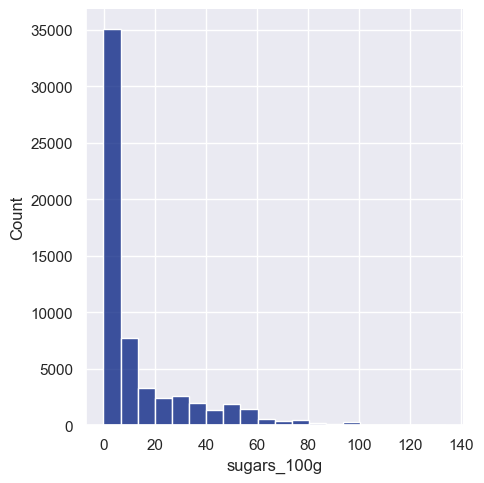

In [56]:
sns.displot(data=filtered_data, x="sugars_100g", kind='hist', bins=20)

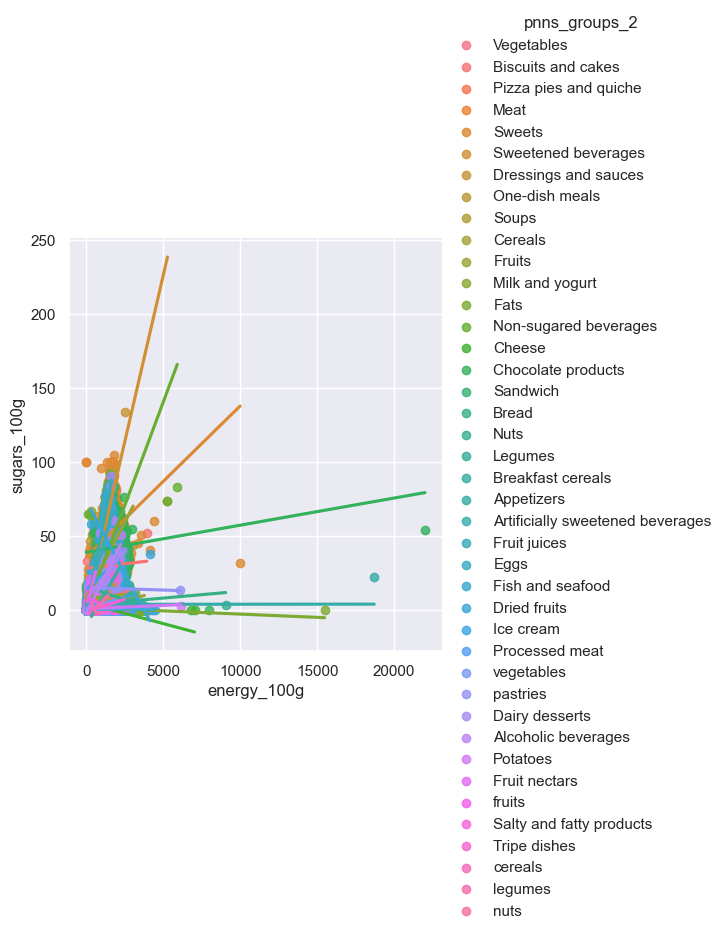

In [78]:
sns.lmplot(data=filtered_data.loc[filtered_data["energy_100g"] < 1.5e6], x="energy_100g", y="sugars_100g", hue="pnns_groups_2", ci=None)